# Config

In [56]:
import warnings
# Filter specific DeprecationWarnings for datetime.utcnow
warnings.filterwarnings("ignore", category=DeprecationWarning, message=".*datetime.datetime.utcnow.*")

import logging
logging.getLogger('jupyter_client').setLevel(logging.ERROR)

import warnings
warnings.filterwarnings('ignore')

In [57]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Text Pre-processing, EDA

In [58]:
import pandas as pd

# Replace these paths with the exact paths printed above
df1 = pd.read_csv('/content/drive/MyDrive/TWA_Project/Data/sssihms_blr.csv')
df2 = pd.read_csv('/content/drive/MyDrive/TWA_Project/Data/sssihms_ptp.csv')

print(" Branch 1 ")
print("Shape:", df1.shape)
print("Columns:", df1.columns.tolist())
print()
print(" Branch 2 ")
print("Shape:", df2.shape)
print("Columns:", df2.columns.tolist())

 Branch 1 
Shape: (2000, 98)
Columns: ['address', 'categories/0', 'categoryName', 'cid', 'city', 'countryCode', 'fid', 'imageUrl', 'isAdvertisement', 'isLocalGuide', 'kgmid', 'language', 'likesCount', 'location/lat', 'location/lng', 'name', 'neighborhood', 'originalLanguage', 'permanentlyClosed', 'placeId', 'postalCode', 'price', 'publishAt', 'publishedAtDate', 'rating', 'responseFromOwnerDate', 'responseFromOwnerText', 'reviewId', 'reviewImageUrls/0', 'reviewImageUrls/1', 'reviewImageUrls/2', 'reviewImageUrls/3', 'reviewImageUrls/4', 'reviewImageUrls/5', 'reviewImageUrls/6', 'reviewImageUrls/7', 'reviewImageUrls/8', 'reviewImageUrls/9', 'reviewImageUrls/10', 'reviewImageUrls/11', 'reviewImageUrls/12', 'reviewImageUrls/13', 'reviewImageUrls/14', 'reviewImageUrls/15', 'reviewImageUrls/16', 'reviewImageUrls/17', 'reviewImageUrls/18', 'reviewImageUrls/19', 'reviewImageUrls/20', 'reviewImageUrls/21', 'reviewImageUrls/22', 'reviewImageUrls/23', 'reviewImageUrls/24', 'reviewImageUrls/25', 'r

In [59]:
import pandas as pd
import numpy as np

# Columns we actually need
KEEP_COLS = [
    'title',              # branch name
    'stars',              # star rating
    'publishedAtDate',    # review date
    'text',               # original review text
    'textTranslated',     # english translation (if review was in another language)
    'language',           # language of review
    'responseFromOwnerText',   # hospital's reply
    'responseFromOwnerDate',   # when hospital replied
    'isLocalGuide',       # is reviewer a Google Local Guide
    'reviewerNumberOfReviews', # reviewer credibility
    'likesCount',         # how many people found review helpful
    'visitedIn',          # month/year they visited
]

def prepare_df(df, branch_name):
    # Keep only available useful columns
    cols = [c for c in KEEP_COLS if c in df.columns]
    df = df[cols].copy()

    # Add branch label
    df['branch'] = branch_name

    # Parse date
    df['date'] = pd.to_datetime(df['publishedAtDate'], errors='coerce')
    df['year'] = df['date'].dt.year
    df['month'] = df['date'].dt.month
    df['year_month'] = df['date'].dt.to_period('M')

    # Use translated text if original is non-English, else use original
    if 'textTranslated' in df.columns:
        df['review'] = df['textTranslated'].fillna(df['text']).fillna('')
    else:
        df['review'] = df['text'].fillna('')

    # Clean owner response
    if 'responseFromOwnerText' in df.columns:
        df['has_owner_response'] = df['responseFromOwnerText'].notna()
    else:
        df['has_owner_response'] = False

    # Clean stars
    df['stars'] = pd.to_numeric(df['stars'], errors='coerce')

    # Flag empty reviews (rating only, no text)
    df['has_text'] = df['review'].str.strip().str.len() > 0

    print(f"\n {branch_name} ")
    print(f"Total reviews      : {len(df)}")
    print(f"Date range         : {df['date'].min().date()} → {df['date'].max().date()}")
    print(f"Avg star rating    : {df['stars'].mean():.2f}")
    print(f"Reviews with text  : {df['has_text'].sum()} ({df['has_text'].mean()*100:.1f}%)")
    print(f"With owner reply   : {df['has_owner_response'].sum()} ({df['has_owner_response'].mean()*100:.1f}%)")
    print(f"Languages found    : {df['language'].nunique() if 'language' in df.columns else 'N/A'}")

    return df

df1_clean = prepare_df(df1, "Branch 1 - Whitefield")
df2_clean = prepare_df(df2, "Branch 2")  # update name once you tell me

# Combined dataframe for comparative analysis
df_all = pd.concat([df1_clean, df2_clean], ignore_index=True)

print(f"\n Combined ")
print(f"Total reviews: {len(df_all)}")


 Branch 1 - Whitefield 
Total reviews      : 2000
Date range         : 2018-06-02 → 2026-03-24
Avg star rating    : 4.28
Reviews with text  : 946 (47.3%)
With owner reply   : 549 (27.5%)
Languages found    : 1

 Branch 2 
Total reviews      : 1110
Date range         : 2013-01-18 → 2026-03-20
Avg star rating    : 4.51
Reviews with text  : 519 (46.8%)
With owner reply   : 16 (1.4%)
Languages found    : 1

 Combined 
Total reviews: 3110


In [60]:
!pip install plotly wordcloud -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 12

print(" All libraries loaded.")

 All libraries loaded.


In [61]:
fig = make_subplots(
    rows=1, cols=2,
    subplot_titles=("Branch 1 - Whitefield", "Branch 2 - Prasanthigram"),
    shared_yaxes=False
)

for i, (df, branch) in enumerate([(df1_clean, "Branch 1"), (df2_clean, "Branch 2")], 1):
    rating_counts = df['stars'].value_counts().sort_index()
    pct = (rating_counts / len(df) * 100).round(1)

    fig.add_trace(
        go.Bar(
            x=rating_counts.index.astype(str) + " star",
            y=rating_counts.values,
            text=[f"{p}%" for p in pct],
            textposition='outside',
            marker_color=['#d73027','#f46d43','#fdae61','#74add1','#313695']
        ),
        row=1, col=i
    )

fig.update_layout(
    title_text=" Star Rating Distribution by Branch",
    title_font_size=18,
    showlegend=False,
    height=450,
    plot_bgcolor='white'
)
fig.update_yaxes(title_text="Number of Reviews")
fig.show()

# Print summary stats
print("\n Rating Summary:")
summary = pd.DataFrame({
    'Branch 1 - Whitefield': df1_clean['stars'].value_counts().sort_index(),
    'Branch 2 - Prasanthigram': df2_clean['stars'].value_counts().sort_index()
})
summary.index = [f"{i} star" for i in summary.index]
summary['B1 %'] = (summary['Branch 1 - Whitefield'] / len(df1_clean) * 100).round(1)
summary['B2 %'] = (summary['Branch 2 - Prasanthigram'] / len(df2_clean) * 100).round(1)
print(summary)


 Rating Summary:
        Branch 1 - Whitefield  Branch 2 - Prasanthigram  B1 %  B2 %
1 star                    255                        81  12.8   7.3
2 star                     43                        21   2.2   1.9
3 star                     60                        28   3.0   2.5
4 star                    164                       101   8.2   9.1
5 star                   1478                       879  73.9  79.2


In [62]:
def get_monthly_counts(df):
    return df.groupby('year_month').size().reset_index(name='count')

m1 = get_monthly_counts(df1_clean)
m2 = get_monthly_counts(df2_clean)

m1['date'] = m1['year_month'].dt.to_timestamp()
m2['date'] = m2['year_month'].dt.to_timestamp()

fig = go.Figure()

fig.add_trace(go.Scatter(
    x=m1['date'], y=m1['count'],
    name='Branch 1 - Whitefield',
    mode='lines',
    line=dict(color='#1f77b4', width=2),
    fill='tozeroy',
    fillcolor='rgba(31,119,180,0.15)'
))

fig.add_trace(go.Scatter(
    x=m2['date'], y=m2['count'],
    name='Branch 2 - Prasanthigram',
    mode='lines',
    line=dict(color='#ff7f0e', width=2),
    fill='tozeroy',
    fillcolor='rgba(255,127,14,0.15)'
))

fig.update_layout(
    title='Review Volume Over Time (Monthly)',
    xaxis_title='Month',
    yaxis_title='Number of Reviews',
    height=450,
    hovermode='x unified',
    plot_bgcolor='white',
    legend=dict(x=0.01, y=0.99)
)
fig.show()

# Yearly breakdown
print("\n Yearly Review Counts:")
yearly = df_all.groupby(['year','branch']).size().unstack(fill_value=0)
print(yearly)


 Yearly Review Counts:
branch  Branch 1 - Whitefield  Branch 2
year                                   
2013                        0         2
2014                        0         6
2015                        0        19
2016                        0        49
2017                        0       146
2018                      251       186
2019                      392       128
2020                      171       100
2021                      185       115
2022                      382       140
2023                      203        79
2024                      193        72
2025                      196        53
2026                       27        15


In [63]:
def yearly_avg_rating(df):
    return df.groupby('year')['stars'].agg(['mean','count']).reset_index()

y1 = yearly_avg_rating(df1_clean)
y2 = yearly_avg_rating(df2_clean)

fig = go.Figure()

fig.add_trace(go.Scatter(
    x=y1['year'], y=y1['mean'].round(2),
    name='Branch 1 - Whitefield',
    mode='lines+markers',
    marker=dict(size=8),
    line=dict(color='#1f77b4', width=2.5)
))

fig.add_trace(go.Scatter(
    x=y2['year'], y=y2['mean'].round(2),
    name='Branch 2 - Prasanthigram',
    mode='lines+markers',
    marker=dict(size=8),
    line=dict(color='#ff7f0e', width=2.5)
))

# Add 4.0 reference line
fig.add_hline(y=4.0, line_dash="dash", line_color="red",
              annotation_text="4.0 benchmark", annotation_position="right")

fig.update_layout(
    title='Average Star Rating Trend by Year',
    xaxis_title='Year',
    yaxis_title='Average Rating',
    yaxis=dict(range=[1, 5.5]),
    height=450,
    hovermode='x unified',
    plot_bgcolor='white'
)
fig.show()

In [64]:
# Owner response rate by year
def response_rate_by_year(df):
    return df.groupby('year')['has_owner_response'].agg(['sum','count']).reset_index().\
           rename(columns={'sum':'responded','count':'total'}).\
           assign(response_rate=lambda x: (x['responded']/x['total']*100).round(1))

r1 = response_rate_by_year(df1_clean)
r2 = response_rate_by_year(df2_clean)

fig = make_subplots(rows=1, cols=2,
    subplot_titles=("Branch 1 - Whitefield", "Branch 2 - Prasanthigram"))

for i, (r, color) in enumerate([(r1,'#1f77b4'), (r2,'#ff7f0e')], 1):
    fig.add_trace(go.Bar(
        x=r['year'], y=r['response_rate'],
        marker_color=color,
        text=[f"{v}%" for v in r['response_rate']],
        textposition='outside',
        name=f"Branch {i}"
    ), row=1, col=i)

fig.update_layout(
    title='Owner Response Rate by Year (%)',
    height=450,
    showlegend=False,
    plot_bgcolor='white'
)
fig.update_yaxes(title_text="Response Rate (%)", range=[0,100])
fig.show()

# Summary
print("\n Overall Owner Response Summary:")
for name, df in [("Branch 1 - Whitefield", df1_clean), ("Branch 2 - Prasanthigram", df2_clean)]:
    total = len(df)
    responded = df['has_owner_response'].sum()
    print(f"  {name}: {responded}/{total} reviews responded to ({responded/total*100:.1f}%)")


 Overall Owner Response Summary:
  Branch 1 - Whitefield: 549/2000 reviews responded to (27.5%)
  Branch 2 - Prasanthigram: 16/1110 reviews responded to (1.4%)


In [65]:
fig = make_subplots(rows=1, cols=2,
    subplot_titles=("Branch 1 - Whitefield", "Branch 2 - Prasanthigram"),
    specs=[[{"type": "domain"}, {"type": "domain"}]])

for i, (df, name) in enumerate([(df1_clean,"Branch 1"), (df2_clean,"Branch 2")], 1):
    counts = df['has_text'].value_counts()
    fig.add_trace(go.Pie(
        labels=['Has Review Text', 'Rating Only'],
        values=[counts.get(True,0), counts.get(False,0)],
        marker_colors=['#2ecc71','#e74c3c'],
        textinfo='label+percent',
        name=name
    ), row=1, col=i)

fig.update_layout(
    title='Reviews With Text vs Rating-Only',
    height=400,
    showlegend=False
)
fig.show()

print("\n Text Review Counts (used for all NLP modules):")
print(f"  Branch 1: {df1_clean['has_text'].sum()} text reviews")
print(f"  Branch 2: {df2_clean['has_text'].sum()} text reviews")
print(f"  Combined: {df_all['has_text'].sum()} text reviews")


 Text Review Counts (used for all NLP modules):
  Branch 1: 946 text reviews
  Branch 2: 519 text reviews
  Combined: 1465 text reviews


In [66]:
if 'isLocalGuide' in df1_clean.columns:
    fig = make_subplots(rows=1, cols=2,
    subplot_titles=("Branch 1 - Whitefield", "Branch 2 - Prasanthigram"),
    specs=[[{"type": "domain"}, {"type": "domain"}]])

    for i, (df, name) in enumerate([(df1_clean,"Branch 1"), (df2_clean,"Branch 2")], 1):
        lg = df['isLocalGuide'].value_counts()
        fig.add_trace(go.Pie(
            labels=['Local Guide','Regular Reviewer'],
            values=[lg.get(True,0), lg.get(False,0)],
            marker_colors=['#9b59b6','#95a5a6'],
            textinfo='label+percent',
            name=name
        ), row=1, col=i)

    fig.update_layout(
        title='Local Guide vs Regular Reviewer Distribution',
        height=400,
        showlegend=False
    )
    fig.show()

    # Do local guides rate differently?
    print("\n Do Local Guides rate differently?")
    for name, df in [("Branch 1", df1_clean), ("Branch 2", df2_clean)]:
        lg_avg = df[df['isLocalGuide']==True]['stars'].mean()
        reg_avg = df[df['isLocalGuide']==False]['stars'].mean()
        print(f"  {name} — Local Guide avg: {lg_avg:.2f} | Regular avg: {reg_avg:.2f}")


 Do Local Guides rate differently?
  Branch 1 — Local Guide avg: 4.42 | Regular avg: 4.20
  Branch 2 — Local Guide avg: 4.61 | Regular avg: 4.44


In [67]:
!pip install spacy -q
!python -m spacy download en_core_web_sm -q

import nltk
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('punkt')
nltk.download('averaged_perceptron_tagger')

print(" NLP resources ready.")
nltk.download('punkt_tab')


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 33.6 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.
 NLP resources ready.


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [68]:
import re
import string
import spacy
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

nlp = spacy.load("en_core_web_sm")
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

# Custom stopwords specific to hospital reviews
# These words appear in almost every review and add no signal
# Custom stopwords specific to hospital reviews
custom_stopwords = {
    'hospital', 'sathya', 'sai', 'sssihms', 'institute', 'medical',
    'science', 'whitefield', 'prasanthigram', 'bangalore', 'bengaluru',
    'sri', 'srinivasa',
    'doctor', 'doctors', 'staff', 'patient', 'patients', 'treatment',
    'visit', 'visited', 'one', 'also', 'get', 'got', 'go', 'going',
    'came', 'come', 'would', 'could', 'really', 'very', 'much',
    'place', 'time',
}

all_stopwords = stop_words.union(custom_stopwords)

print(f" Total stopwords: {len(all_stopwords)}")
print(f"   NLTK stopwords : {len(stop_words)}")
print(f"   Custom added   : {len(custom_stopwords)}")

 Total stopwords: 233
   NLTK stopwords : 198
   Custom added   : 36


In [69]:
def clean_text(text):
    """Full preprocessing pipeline for a single review."""
    if not isinstance(text, str) or text.strip() == '':
        return ''

    # 1. Lowercase
    text = text.lower()

    # 2. Remove URLs
    text = re.sub(r'http\S+|www\S+', '', text)

    # 3. Remove emails
    text = re.sub(r'\S+@\S+', '', text)

    # 4. Remove numbers
    text = re.sub(r'\d+', '', text)

    # 5. Remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))

    # 6. Remove extra whitespace
    text = re.sub(r'\s+', ' ', text).strip()

    # 7. Tokenize
    tokens = word_tokenize(text)

    # 8. Remove stopwords + short tokens
    tokens = [t for t in tokens if t not in all_stopwords and len(t) > 2]

    # 9. Lemmatize
    tokens = [lemmatizer.lemmatize(t) for t in tokens]

    return ' '.join(tokens)


In [70]:
print("Preprocessing Branch 1 reviews...")
df1_clean['review_clean'] = df1_clean['review'].apply(clean_text)

print("Preprocessing Branch 2 reviews...")
df2_clean['review_clean'] = df2_clean['review'].apply(clean_text)

# Propagate to combined df
df_all = pd.concat([df1_clean, df2_clean], ignore_index=True)

# Filter to only text reviews for NLP tasks
df1_text = df1_clean[df1_clean['has_text'] & (df1_clean['review_clean'].str.len() > 0)].copy()
df2_text = df2_clean[df2_clean['has_text'] & (df2_clean['review_clean'].str.len() > 0)].copy()
df_all_text = pd.concat([df1_text, df2_text], ignore_index=True)

print(f"\n Preprocessing complete!")
print(f"   Branch 1 — {len(df1_text)} usable text reviews")
print(f"   Branch 2 — {len(df2_text)} usable text reviews")
print(f"   Combined — {len(df_all_text)} usable text reviews")

Preprocessing Branch 1 reviews...
Preprocessing Branch 2 reviews...

 Preprocessing complete!
   Branch 1 — 934 usable text reviews
   Branch 2 — 516 usable text reviews
   Combined — 1450 usable text reviews


In [71]:
# Show 5 random before/after examples
print("SAMPLE BEFORE vs AFTER CLEANING")


samples = df1_text[df1_text['review'].str.len() > 50].sample(5, random_state=42)

for i, (_, row) in enumerate(samples.iterrows(), 1):
    print(f"\n[{i}] ORIGINAL:\n  {row['review'][:200]}")
    print(f"    CLEANED:\n  {row['review_clean'][:200]}")
    print("-" * 80)

# Token count stats
df1_text['token_count'] = df1_text['review_clean'].str.split().str.len()
df2_text['token_count'] = df2_text['review_clean'].str.split().str.len()

print("\n Token Count Stats After Cleaning:")
print(f"  Branch 1 — avg: {df1_text['token_count'].mean():.1f} | "
      f"min: {df1_text['token_count'].min()} | "
      f"max: {df1_text['token_count'].max()}")
print(f"  Branch 2 — avg: {df2_text['token_count'].mean():.1f} | "
      f"min: {df2_text['token_count'].min()} | "
      f"max: {df2_text['token_count'].max()}")

SAMPLE BEFORE vs AFTER CLEANING

[1] ORIGINAL:
  Very good, only problem is 8 AM entry it is 30 km from my place
    CLEANED:
  good problem entry
--------------------------------------------------------------------------------

[2] ORIGINAL:
  Interventional Cardiology, Cardiac Anesthesia, Critical Care Anesthesia and Cross sectional imaging. In the paramedical field, Hospital provides BSc Nursing, BSc Imaging Technology, BSc Perfusion Tech
    CLEANED:
  interventional cardiology cardiac anesthesia critical care anesthesia cross sectional imaging paramedical field provides bsc nursing bsc imaging technology bsc perfusion technology bsc anesthesia tech
--------------------------------------------------------------------------------

[3] ORIGINAL:
  My cousin visited with his son. Doctors are asking to take x-ray and other tests from an outside private hospital. The doctor is writing this in the letter pad of that private hospital.. so what does 
    CLEANED:
  cousin son asking take x

In [75]:
# Filter out reviews with fewer than 3 tokens after cleaning
# (these are too sparse for LDA, clustering etc.)
df1_text = df1_text[df1_text['review_clean'].str.split().str.len() >= 3].copy()
df2_text = df2_text[df2_text['review_clean'].str.split().str.len() >= 3].copy()
df_all_text = pd.concat([df1_text, df2_text], ignore_index=True)

print(" Filtered short reviews.")
print(f"   Branch 1 — {len(df1_text)} reviews remaining")
print(f"   Branch 2 — {len(df2_text)} reviews remaining")
print(f"   Combined — {len(df_all_text)} reviews remaining")

 Filtered short reviews.
   Branch 1 — 614 reviews remaining
   Branch 2 — 330 reviews remaining
   Combined — 944 reviews remaining


In [76]:
!pip install wordcloud -q

from wordcloud import WordCloud
from collections import Counter
import itertools

print(" WordCloud ready.")

 WordCloud ready.


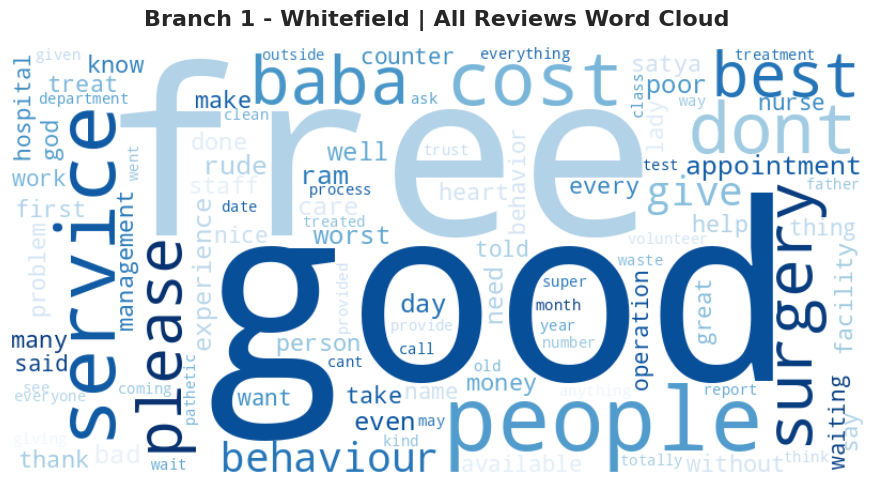

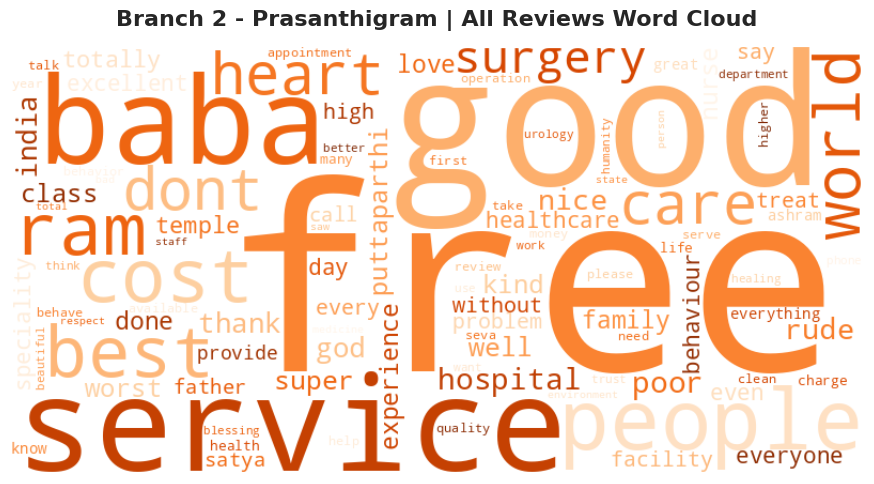

In [77]:
def generate_wordcloud(text_series, title, colormap='Blues'):
    text = ' '.join(text_series.dropna())
    wc = WordCloud(
        width=800, height=400,
        background_color='white',
        colormap=colormap,
        max_words=100,
        collocations=False  # avoids duplicate bigrams
    ).generate(text)

    plt.figure(figsize=(12, 5))
    plt.imshow(wc, interpolation='bilinear')
    plt.axis('off')
    plt.title(title, fontsize=16, fontweight='bold', pad=15)
    plt.tight_layout()
    plt.show()

generate_wordcloud(df1_text['review_clean'],
                   "Branch 1 - Whitefield | All Reviews Word Cloud",
                   colormap='Blues')

generate_wordcloud(df2_text['review_clean'],
                   "Branch 2 - Prasanthigram | All Reviews Word Cloud",
                   colormap='Oranges')

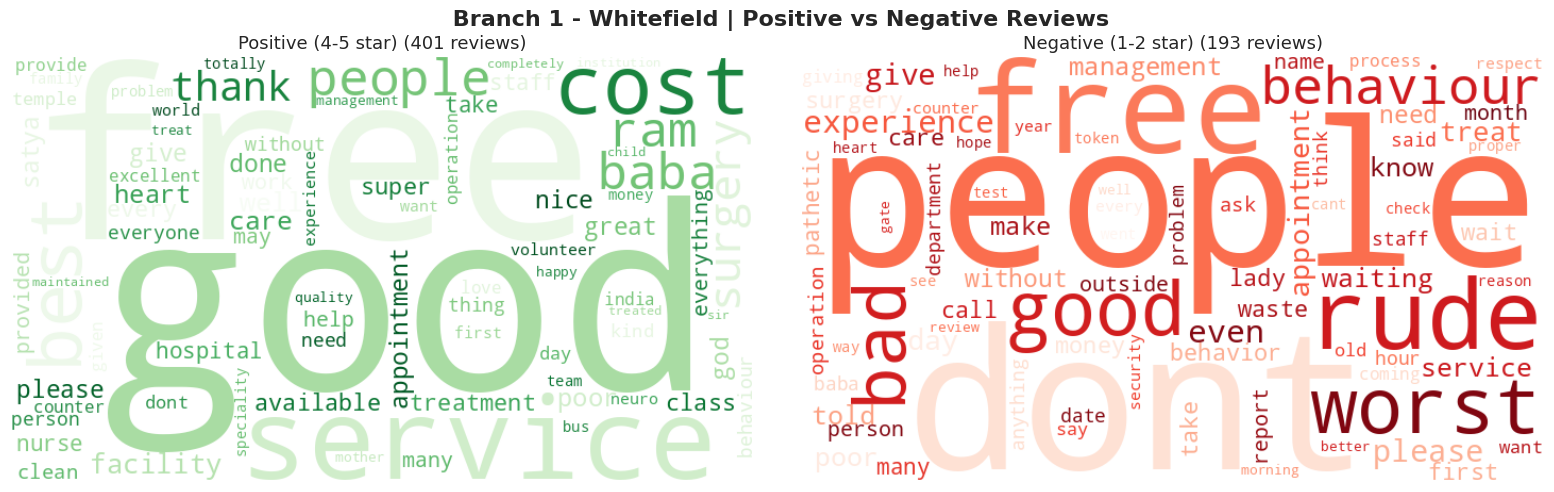

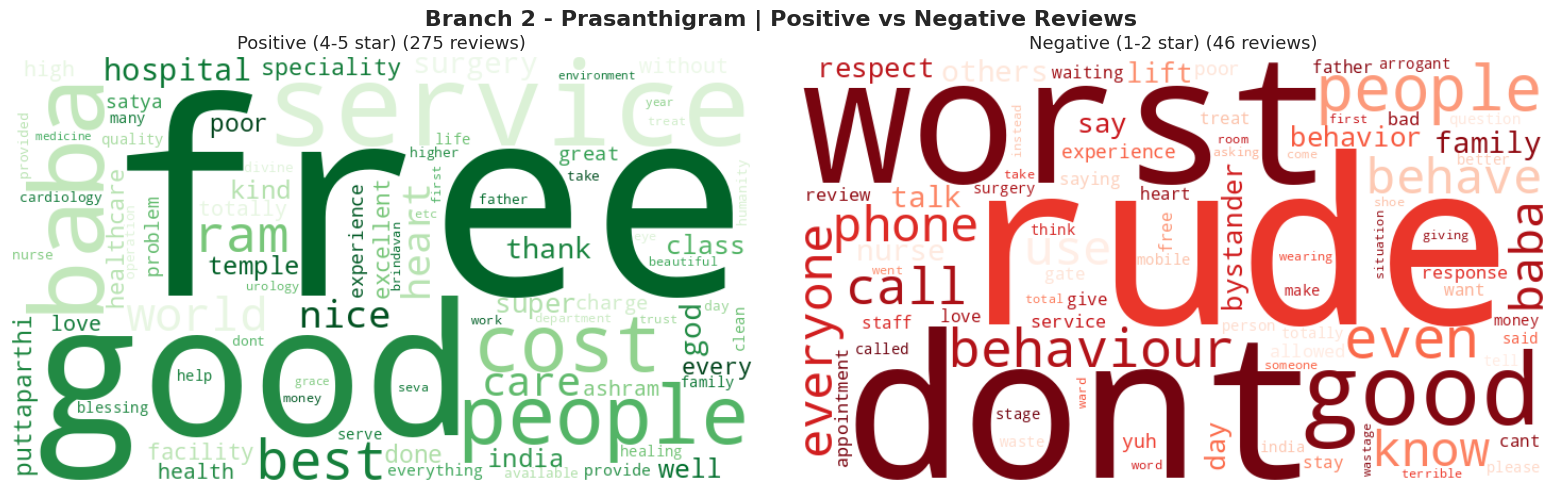

In [78]:
for branch_name, df in [("Branch 1 - Whitefield", df1_text),
                          ("Branch 2 - Prasanthigram", df2_text)]:

    pos_reviews = df[df['stars'] >= 4]['review_clean']
    neg_reviews = df[df['stars'] <= 2]['review_clean']

    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    fig.suptitle(f"️ {branch_name} | Positive vs Negative Reviews",
                 fontsize=16, fontweight='bold')

    for ax, reviews, label, cmap in zip(
        axes,
        [pos_reviews, neg_reviews],
        ['Positive (4-5 star)', 'Negative (1-2 star)'],
        ['Greens', 'Reds']
    ):
        if len(reviews) == 0:
            ax.text(0.5, 0.5, 'No reviews', ha='center')
            continue

        text = ' '.join(reviews.dropna())
        wc = WordCloud(
            width=700, height=400,
            background_color='white',
            colormap=cmap,
            max_words=80,
            collocations=False
        ).generate(text)

        ax.imshow(wc, interpolation='bilinear')
        ax.axis('off')
        ax.set_title(f"{label} ({len(reviews)} reviews)", fontsize=13)

    plt.tight_layout()
    plt.show()

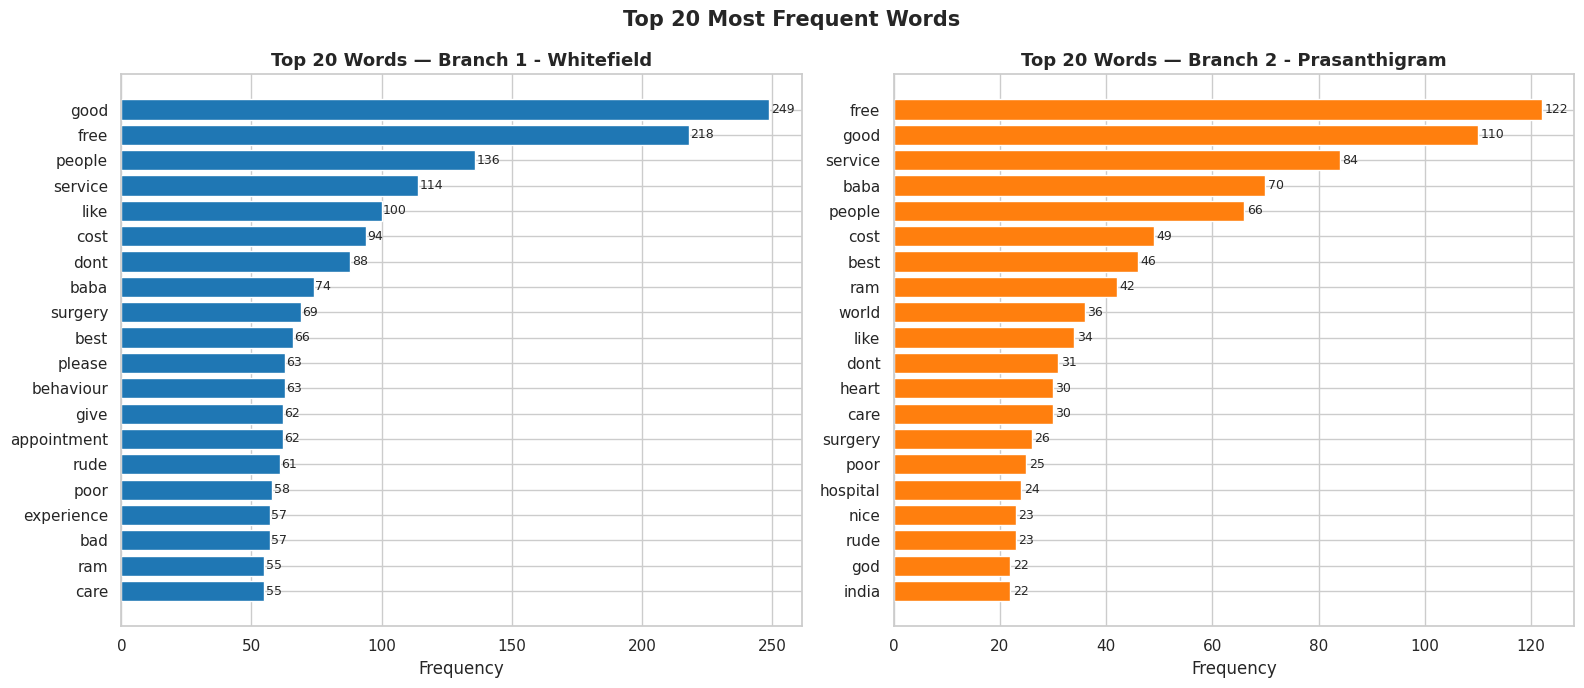

In [79]:
def get_top_ngrams(text_series, n=1, top_k=20):
    all_tokens = []
    for text in text_series.dropna():
        tokens = text.split()
        if n == 1:
            all_tokens.extend(tokens)
        else:
            all_tokens.extend([' '.join(tokens[i:i+n])
                               for i in range(len(tokens)-n+1)])
    return Counter(all_tokens).most_common(top_k)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

for ax, (df, name, color) in zip(axes, [
    (df1_text, "Branch 1 - Whitefield", "#1f77b4"),
    (df2_text, "Branch 2 - Prasanthigram", "#ff7f0e")
]):
    top = get_top_ngrams(df['review_clean'], n=1, top_k=20)
    words, counts = zip(*top)

    ax.barh(words[::-1], counts[::-1], color=color, edgecolor='white')
    ax.set_title(f"Top 20 Words — {name}", fontsize=13, fontweight='bold')
    ax.set_xlabel("Frequency")
    for i, (w, c) in enumerate(zip(words[::-1], counts[::-1])):
        ax.text(c + 0.5, i, str(c), va='center', fontsize=9)

plt.suptitle("Top 20 Most Frequent Words", fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

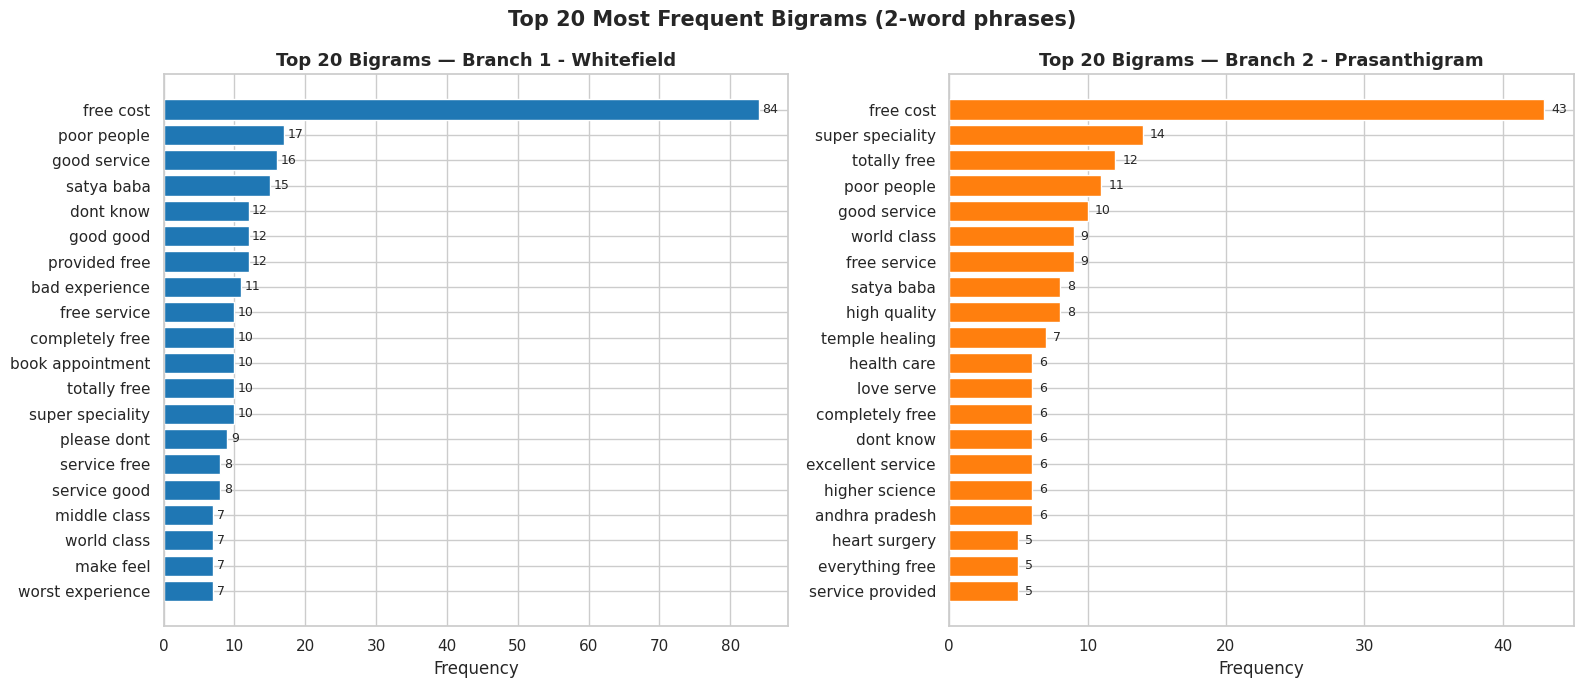

In [80]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

for ax, (df, name, color) in zip(axes, [
    (df1_text, "Branch 1 - Whitefield", "#1f77b4"),
    (df2_text, "Branch 2 - Prasanthigram", "#ff7f0e")
]):
    top = get_top_ngrams(df['review_clean'], n=2, top_k=20)
    bigrams, counts = zip(*top)

    ax.barh(bigrams[::-1], counts[::-1], color=color, edgecolor='white')
    ax.set_title(f"Top 20 Bigrams — {name}", fontsize=13, fontweight='bold')
    ax.set_xlabel("Frequency")
    for i, (b, c) in enumerate(zip(bigrams[::-1], counts[::-1])):
        ax.text(c + 0.5, i, str(c), va='center', fontsize=9)

plt.suptitle("Top 20 Most Frequent Bigrams (2-word phrases)",
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

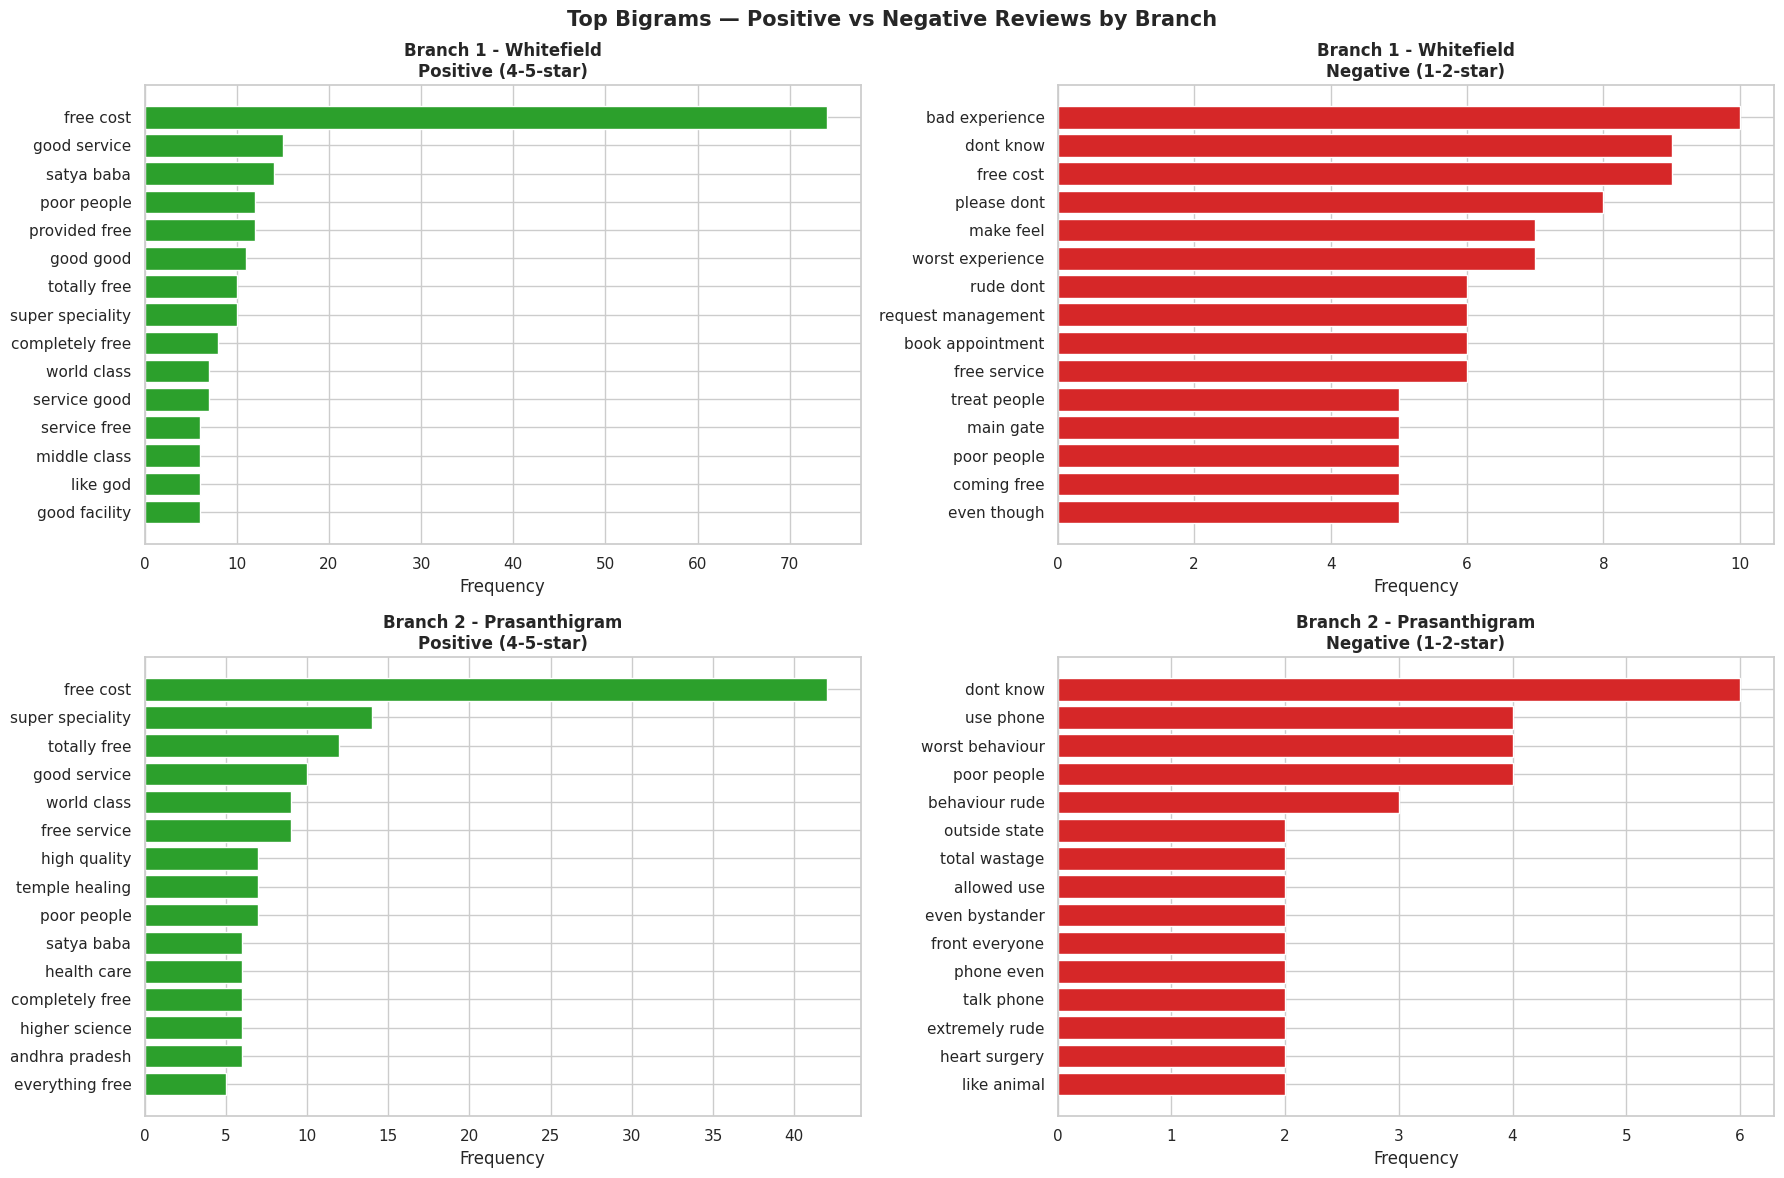

In [81]:
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

for row, (df, branch_name) in enumerate([
    (df1_text, "Branch 1 - Whitefield"),
    (df2_text, "Branch 2 - Prasanthigram")
]):
    for col, (label, stars_filter, color) in enumerate([
        ("Positive (4-5-star)", df['stars'] >= 4, '#2ca02c'),
        ("Negative (1-2-star)", df['stars'] <= 2, '#d62728')
    ]):
        subset = df[stars_filter]['review_clean']
        if len(subset) < 5:
            axes[row][col].text(0.5, 0.5, 'Not enough data', ha='center')
            continue

        top = get_top_ngrams(subset, n=2, top_k=15)
        bigrams, counts = zip(*top)

        axes[row][col].barh(bigrams[::-1], counts[::-1],
                             color=color, edgecolor='white')
        axes[row][col].set_title(f"{branch_name}\n{label}",
                                  fontsize=12, fontweight='bold')
        axes[row][col].set_xlabel("Frequency")

plt.suptitle("Top Bigrams — Positive vs Negative Reviews by Branch",
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

# VADER - A Lexicon and Rule-based Sentiment Analysis

In [82]:
nltk.download('vader_lexicon')

from nltk.sentiment.vader import SentimentIntensityAnalyzer

sia = SentimentIntensityAnalyzer()

# Add domain-specific words to VADER's lexicon
# These are words that carry stronger sentiment in a hospital context
sia.lexicon.update({
    #'free': 2.0,          # free treatment is very positive here
    'brokerage': -2.5,    # very negative in this context
    'harass': -3.0,
    'rude': -2.5,
    'caring': 2.5,
    'compassionate': 3.0,
    'negligent': -3.0,
    'negligence': -3.0,
    'clean': 1.5,
    'dirty': -2.0,
    'delay': -1.5,
    'delayed': -1.5,
    'waiting': -1.0,
    'corruption': -3.0,
    'bribe': -3.0,
    'excellent': 2.5,
    'pathetic': -2.5,
    'worst': -3.0,
    'died': -3.0,
    'death': -2.5,
    'miracle': 3.0,
    'blessed': 2.5,
})

print(" VADER loaded with custom hospital lexicon.")

 VADER loaded with custom hospital lexicon.


[nltk_data] Downloading package vader_lexicon to /root/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


In [83]:
def get_vader_sentiment(text):
    """Returns compound score and sentiment label."""
    if not isinstance(text, str) or text.strip() == '':
        return None, 'neutral'

    scores = sia.polarity_scores(text)
    compound = scores['compound']

    if compound >= 0.05:
        label = 'positive'
    elif compound <= -0.05:
        label = 'negative'
    else:
        label = 'neutral'

    return compound, label

# Apply to ALL reviews (using original uncleaned text — VADER works better on raw text)
for df, name in [(df1_clean, "Branch 1"), (df2_clean, "Branch 2"), (df_all, "Combined")]:
    df[['vader_score', 'vader_label']] = df['review'].apply(
        lambda x: pd.Series(get_vader_sentiment(x))
    )
    print(f" {name} — VADER scoring complete.")

# Also apply to text-only subsets
for df in [df1_text, df2_text, df_all_text]:
    df[['vader_score', 'vader_label']] = df['review'].apply(
        lambda x: pd.Series(get_vader_sentiment(x))
    )

print("\n VADER Sentiment Distribution:")
for name, df in [("Branch 1", df1_clean), ("Branch 2", df2_clean)]:
    dist = df['vader_label'].value_counts(normalize=True) * 100
    print(f"\n  {name}:")
    for label in ['positive', 'neutral', 'negative']:
        print(f"    {label:10s}: {dist.get(label, 0):.1f}%")

 Branch 1 — VADER scoring complete.
 Branch 2 — VADER scoring complete.
 Combined — VADER scoring complete.

 VADER Sentiment Distribution:

  Branch 1:
    positive  : 33.4%
    neutral   : 58.5%
    negative  : 8.2%

  Branch 2:
    positive  : 35.6%
    neutral   : 59.7%
    negative  : 4.7%


In [84]:
fig = make_subplots(rows=1, cols=2,
    subplot_titles=("Branch 1 - Whitefield", "Branch 2 - Prasanthigram"),
    specs=[[{"type": "domain"}, {"type": "domain"}]])

colors = {'positive': '#2ecc71', 'neutral': '#f39c12', 'negative': '#e74c3c'}

for i, (df, name) in enumerate([(df1_clean, "Branch 1"), (df2_clean, "Branch 2")], 1):
    dist = df['vader_label'].value_counts()
    fig.add_trace(go.Pie(
        labels=dist.index.tolist(),
        values=dist.values.tolist(),
        marker_colors=[colors.get(l, '#95a5a6') for l in dist.index],
        textinfo='label+percent',
        name=name,
        hole=0.4
    ), row=1, col=i)

fig.update_layout(
    title='VADER Sentiment Distribution by Branch',
    height=420,
    showlegend=True
)
fig.show()

In [85]:
fig = make_subplots(rows=1, cols=2,
    subplot_titles=("Branch 1 - Whitefield", "Branch 2 - Prasanthigram"))

for i, (df, name) in enumerate([(df1_clean, "Branch 2"), (df2_clean, "Branch 2")], 1):
    avg_vader = df.groupby('stars')['vader_score'].mean().reset_index()

    fig.add_trace(go.Bar(
        x=avg_vader['stars'].astype(str) + ' star',
        y=avg_vader['vader_score'].round(3),
        marker_color=['#e74c3c','#e67e22','#f1c40f','#2ecc71','#27ae60'],
        text=avg_vader['vader_score'].round(3),
        textposition='outside',
        name=name
    ), row=1, col=i)

fig.add_hline(y=0, line_dash="dash", line_color="black")
fig.update_layout(
    title='Average VADER Score per Star Rating (Validation Check)',
    height=450,
    showlegend=False,
    plot_bgcolor='white'
)
fig.update_yaxes(title_text="Avg VADER Compound Score", range=[-1, 1])
fig.show()

# Correlation
for name, df in [("Branch 1", df1_clean), ("Branch 2", df2_clean)]:
    corr = df[['stars','vader_score']].dropna().corr().iloc[0,1]
    print(f"  {name} — Pearson correlation (stars vs VADER): {corr:.3f}")

  Branch 1 — Pearson correlation (stars vs VADER): 0.558
  Branch 2 — Pearson correlation (stars vs VADER): 0.517


In [86]:
# Monthly average VADER score per branch
def monthly_sentiment(df):
    return df.groupby('year_month').agg(
        avg_vader=('vader_score', 'mean'),
        review_count=('vader_score', 'count')
    ).reset_index()

ms1 = monthly_sentiment(df1_clean)
ms2 = monthly_sentiment(df2_clean)

ms1['date'] = ms1['year_month'].dt.to_timestamp()
ms2['date'] = ms2['year_month'].dt.to_timestamp()

fig = go.Figure()

fig.add_trace(go.Scatter(
    x=ms1['date'], y=ms1['avg_vader'].round(3),
    name='Branch 1 - Whitefield',
    mode='lines',
    line=dict(color='#1f77b4', width=1.5),
))

# Branch 1 smoothed trend
ms1_smooth = ms1.copy()
ms1_smooth['smoothed'] = ms1['avg_vader'].rolling(window=6, min_periods=1).mean()
fig.add_trace(go.Scatter(
    x=ms1_smooth['date'], y=ms1_smooth['smoothed'].round(3),
    name='Branch 1 (6-month trend)',
    mode='lines',
    line=dict(color='#1f77b4', width=3, dash='solid'),
))

fig.add_trace(go.Scatter(
    x=ms2['date'], y=ms2['avg_vader'].round(3),
    name='Branch 2 - Prasanthigram',
    mode='lines',
    line=dict(color='#ff7f0e', width=1.5),
))

# Branch 2 smoothed trend
ms2_smooth = ms2.copy()
ms2_smooth['smoothed'] = ms2['avg_vader'].rolling(window=6, min_periods=1).mean()
fig.add_trace(go.Scatter(
    x=ms2_smooth['date'], y=ms2_smooth['smoothed'].round(3),
    name='Branch 2 (6-month trend)',
    mode='lines',
    line=dict(color='#ff7f0e', width=3),
))

fig.add_hline(y=0, line_dash="dash", line_color="red",
              annotation_text="Neutral boundary", annotation_position="right")

fig.update_layout(
    title='Sentiment Trend Over Time (Monthly avg VADER score)',
    xaxis_title='Month',
    yaxis_title='Avg VADER Compound Score',
    height=500,
    hovermode='x unified',
    plot_bgcolor='white',
    legend=dict(x=0.01, y=0.01)
)
fig.show()

In [87]:
def yearly_sentiment_dist(df):
    return df.groupby(['year', 'vader_label']).size().unstack(fill_value=0)

y1 = yearly_sentiment_dist(df1_clean)
y2 = yearly_sentiment_dist(df2_clean)

fig = make_subplots(rows=1, cols=2,
    subplot_titles=("Branch 1 - Whitefield", "Branch 2 - Prasanthigram"))

for col, (ys, name) in enumerate([(y1, "Branch 1"), (y2, "Branch 2")], 1):
    for label, color in [('positive','#2ecc71'), ('neutral','#f39c12'), ('negative','#e74c3c')]:
        if label in ys.columns:
            fig.add_trace(go.Bar(
                x=ys.index.astype(str),
                y=ys[label],
                name=label.capitalize(),
                marker_color=color,
                showlegend=(col == 1)
            ), row=1, col=col)

fig.update_layout(
    barmode='stack',
    title='Yearly Sentiment Breakdown by Branch',
    height=480,
    plot_bgcolor='white',
    legend=dict(x=1.02, y=0.5)
)
fig.update_xaxes(title_text="Year")
fig.update_yaxes(title_text="Number of Reviews")
fig.show()

In [88]:
fig = make_subplots(rows=1, cols=2,
    subplot_titles=("Branch 1 - Whitefield", "Branch 2 - Prasanthigram"))

for i, (df, name) in enumerate([(df1_clean, "Branch 1"), (df2_clean, "Branch 2")], 1):
    avg = df.groupby('has_owner_response')['vader_score'].mean().reset_index()
    avg['label'] = avg['has_owner_response'].map({True: 'With Owner Reply',
                                                   False: 'No Owner Reply'})

    fig.add_trace(go.Bar(
        x=avg['label'],
        y=avg['vader_score'].round(3),
        marker_color=['#27ae60', '#e74c3c'],
        text=avg['vader_score'].round(3),
        textposition='outside',
        name=name
    ), row=1, col=i)

fig.update_layout(
    title='Owner Response vs Review Sentiment',
    height=450,
    showlegend=False,
    plot_bgcolor='white'
)
fig.update_yaxes(title_text="Avg VADER Score", range=[-0.5, 1.0])
fig.show()

print("\n Insight — Owner Response vs Sentiment:")
for name, df in [("Branch 1", df1_clean), ("Branch 2", df2_clean)]:
    with_reply = df[df['has_owner_response']==True]['vader_score'].mean()
    without = df[df['has_owner_response']==False]['vader_score'].mean()
    print(f"  {name}: With reply={with_reply:.3f} | Without reply={without:.3f}")


 Insight — Owner Response vs Sentiment:
  Branch 1: With reply=0.450 | Without reply=0.276
  Branch 2: With reply=-0.001 | Without reply=0.458


In [89]:
def show_free_context(df, branch_name, n=5):
    print(f" {branch_name}")
    print(f"{'-'*70}")

    # Filter reviews mentioning "free"
    free_reviews = df[df['review'].str.contains(r'\bfree\b', case=False, na=False)].copy()
    print(f"\nTotal reviews mentioning 'free': {len(free_reviews)}")
    print(f"  Positive: {(free_reviews['vader_label']=='positive').sum()}")
    print(f"  Neutral : {(free_reviews['vader_label']=='neutral').sum()}")
    print(f"  Negative: {(free_reviews['vader_label']=='negative').sum()}")

    for label, color_tag in [('positive', '[+]'), ('negative', '[-]')]:
        subset = free_reviews[free_reviews['vader_label'] == label]
        print(f"\n{color_tag} {label.upper()} reviews mentioning 'free' (showing {min(n, len(subset))}):")

        for j, (_, row) in enumerate(subset.head(n).iterrows()):
            # Find sentence(s) containing "free"
            sentences = row['review'].split('.')
            free_sentences = [s.strip() for s in sentences
                            if 'free' in s.lower() and s.strip()]

            context = ' ... '.join(free_sentences) if free_sentences else row['review'][:200]
            print(f"  [{j+1}] {int(row['stars']) if pd.notna(row['stars']) else '?'} | "
                  f"VADER: {row['vader_score']:.3f}")
            print(f"       Context: {context[:250]}")
            print()

show_free_context(df1_clean, "Branch 1 - Whitefield")
print('\n')
show_free_context(df2_clean, "Branch 2 - Prasanthigram")

 Branch 1 - Whitefield
----------------------------------------------------------------------

Total reviews mentioning 'free': 186
  Positive: 160
  Neutral : 4
  Negative: 22

[+] POSITIVE reviews mentioning 'free' (showing 5):
  [1] 1 | VADER: 0.962
       Context: JUST COZ ITS FREE DOESNT MEAN THEY TREAT PROPLE CHEAPLY

  [2] 1 | VADER: 0.952
       Context: For their vision of free health benifits to poor was really appreciated

  [3] 5 | VADER: 0.929
       Context: Free medical services

  [4] 1 | VADER: 0.989
       Context: There is no denying that Sri Sathya Sai Institute of Higher Medical Sciences, Whitefield is a remarkable institution in terms of infrastructure and the noble idea of providing completely free, world-class medical treatment ... Among them are many who

  [5] 2 | VADER: 0.989
       Context: I am genuinely grateful that Sri Sathya Sai Institute of Higher Medical Sciences, Whitefield provides advanced medical treatment completely free of cost ... Despite being

# ML-based Sentiment Analysis

In [90]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.pipeline import Pipeline
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

print(" ML libraries ready.")

 ML libraries ready.


In [91]:
def create_sentiment_label(stars):
    if stars <= 3:
        return 'negative'  # 1-star, 2-star, 3-star → negative
    else:
        return 'positive'  # 4-star, 5-star → positive

for df in [df1_text, df2_text, df_all_text]:
    df['sentiment_label'] = df['stars'].apply(create_sentiment_label)

# Check distribution
print(" Final Binary Label Distribution:")
for name, df in [("Branch 1", df1_text), ("Branch 2", df2_text), ("Combined", df_all_text)]:
    dist = df['sentiment_label'].value_counts()
    total = len(df)
    print(f"\n  {name}:")
    for label in ['positive', 'negative']:
        count = dist.get(label, 0)
        bar = '█' * int(count/total*40)
        print(f"    {label:10s}: {count:4d} ({count/total*100:.1f}%) {bar}")

 Final Binary Label Distribution:

  Branch 1:
    positive  :  401 (65.3%) ██████████████████████████
    negative  :  213 (34.7%) █████████████

  Branch 2:
    positive  :  275 (83.3%) █████████████████████████████████
    negative  :   55 (16.7%) ██████

  Combined:
    positive  :  676 (71.6%) ████████████████████████████
    negative  :  268 (28.4%) ███████████


In [92]:
def train_and_evaluate(df, branch_name):
    print(f" {branch_name}")
    print(f"{'-'*65}")

    df = df[df['review_clean'].str.strip().str.len() > 0].dropna(
        subset=['review_clean', 'sentiment_label'])

    X = df['review_clean']
    y = df['sentiment_label']

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )
    print(f"\nTrain size: {len(X_train)} | Test size: {len(X_test)}")

    tfidf = TfidfVectorizer(
        max_features=5000,
        ngram_range=(1, 2),
        min_df=2,
        sublinear_tf=True
    )

    models = {
        'Naive Bayes'         : MultinomialNB(alpha=0.5),
        'Logistic Regression' : LogisticRegression(
                                    max_iter=1000,
                                    random_state=42,
                                    C=1.0,
                                    class_weight='balanced'
                                ),
        'SVM (LinearSVC)'     : LinearSVC(
                                    max_iter=2000,
                                    random_state=42,
                                    C=1.0,
                                    class_weight='balanced'
                                )
    }

    results = {}

    for model_name, model in models.items():
        pipeline = Pipeline([
            ('tfidf', tfidf),
            ('clf', model)
        ])

        pipeline.fit(X_train, y_train)
        y_pred = pipeline.predict(X_test)

        acc = accuracy_score(y_test, y_pred)
        report = classification_report(y_test, y_pred,
                                        output_dict=True,
                                        zero_division=0)
        cm = confusion_matrix(y_test, y_pred,
                              labels=['negative', 'positive'])

        results[model_name] = {
            'pipeline' : pipeline,
            'accuracy' : acc,
            'report'   : report,
            'cm'       : cm,
            'y_test'   : y_test,
            'y_pred'   : y_pred
        }

        print(f"\n   {model_name}")
        print(f"     Accuracy : {acc*100:.2f}%")
        print(f"     Macro F1 : {report['macro avg']['f1-score']:.3f}")
        print(f"     Neg F1   : {report.get('negative', {}).get('f1-score', 0):.3f}")
        print(f"     Pos F1   : {report.get('positive', {}).get('f1-score', 0):.3f}")

    return results, X_test, y_test

# Train per branch and combined
results_b1, X_test_b1, y_test_b1 = train_and_evaluate(df1_text, "Branch 1 - Whitefield")
print('\n\n')
results_b2, X_test_b2, y_test_b2 = train_and_evaluate(df2_text, "Branch 2 - Prasanthigram")
print('\n\n')
results_combined, X_test_comb, y_test_comb = train_and_evaluate(df_all_text, "Combined")

 Branch 1 - Whitefield
-----------------------------------------------------------------

Train size: 491 | Test size: 123

   Naive Bayes
     Accuracy : 89.43%
     Macro F1 : 0.879
     Neg F1   : 0.835
     Pos F1   : 0.922

   Logistic Regression
     Accuracy : 91.06%
     Macro F1 : 0.900
     Neg F1   : 0.867
     Pos F1   : 0.933

   SVM (LinearSVC)
     Accuracy : 87.80%
     Macro F1 : 0.864
     Neg F1   : 0.819
     Pos F1   : 0.908



 Branch 2 - Prasanthigram
-----------------------------------------------------------------

Train size: 264 | Test size: 66

   Naive Bayes
     Accuracy : 90.91%
     Macro F1 : 0.787
     Neg F1   : 0.625
     Pos F1   : 0.948

   Logistic Regression
     Accuracy : 87.88%
     Macro F1 : 0.782
     Neg F1   : 0.636
     Pos F1   : 0.927

   SVM (LinearSVC)
     Accuracy : 86.36%
     Macro F1 : 0.723
     Neg F1   : 0.526
     Pos F1   : 0.920



 Combined
-----------------------------------------------------------------

Train size: 755

In [93]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.pipeline import Pipeline

def fine_tune(df, branch_name):
    print(f" Fine-tuning — {branch_name}")
    print(f"{'-'*65}")

    df = df[df['review_clean'].str.strip().str.len() > 0].dropna(
        subset=['review_clean', 'sentiment_label'])

    X = df['review_clean']
    y = df['sentiment_label']

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y)

    # 5-fold stratified CV — robust for imbalanced data
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    # Logistic Regression
    pipe_lr = Pipeline([
        ('tfidf', TfidfVectorizer(sublinear_tf=True)),
        ('clf',   LogisticRegression(max_iter=1000,
                                      random_state=42,
                                      class_weight='balanced'))
    ])

    param_grid_lr = {
        'tfidf__max_features' : [3000, 5000, 8000],
        'tfidf__ngram_range'  : [(1,1), (1,2), (1,3)],
        'tfidf__min_df'       : [1, 2, 3],
        'clf__C'              : [0.1, 0.5, 1.0, 2.0, 5.0],
    }

    gs_lr = GridSearchCV(pipe_lr, param_grid_lr,
                          cv=cv, scoring='f1_macro',
                          n_jobs=-1, verbose=0)
    gs_lr.fit(X_train, y_train)

    # Naive Bayes
    pipe_nb = Pipeline([
        ('tfidf', TfidfVectorizer(sublinear_tf=True)),
        ('clf',   MultinomialNB())
    ])

    param_grid_nb = {
        'tfidf__max_features' : [3000, 5000, 8000],
        'tfidf__ngram_range'  : [(1,1), (1,2)],
        'tfidf__min_df'       : [1, 2, 3],
        'clf__alpha'          : [0.1, 0.3, 0.5, 1.0, 2.0],
    }

    gs_nb = GridSearchCV(pipe_nb, param_grid_nb,
                          cv=cv, scoring='f1_macro',
                          n_jobs=-1, verbose=0)
    gs_nb.fit(X_train, y_train)

    # SVM
    pipe_svm = Pipeline([
        ('tfidf', TfidfVectorizer(sublinear_tf=True)),
        ('clf',   LinearSVC(max_iter=2000,
                             random_state=42,
                             class_weight='balanced'))
    ])

    param_grid_svm = {
        'tfidf__max_features' : [3000, 5000, 8000],
        'tfidf__ngram_range'  : [(1,1), (1,2)],
        'tfidf__min_df'       : [1, 2, 3],
        'clf__C'              : [0.1, 0.5, 1.0, 2.0, 5.0],
    }

    gs_svm = GridSearchCV(pipe_svm, param_grid_svm,
                           cv=cv, scoring='f1_macro',
                           n_jobs=-1, verbose=0)
    gs_svm.fit(X_train, y_train)

    # Evaluate all three
    tuned_results = {}

    for name, gs in [('Logistic Regression', gs_lr),
                      ('Naive Bayes',         gs_nb),
                      ('SVM (LinearSVC)',      gs_svm)]:

        y_pred = gs.predict(X_test)
        acc    = accuracy_score(y_test, y_pred)
        report = classification_report(y_test, y_pred,
                                        output_dict=True,
                                        zero_division=0)
        cm     = confusion_matrix(y_test, y_pred,
                                   labels=['negative','positive'])

        tuned_results[name] = {
            'pipeline'   : gs.best_estimator_,
            'best_params': gs.best_params_,
            'cv_f1'      : gs.best_score_,
            'accuracy'   : acc,
            'report'     : report,
            'cm'         : cm,
            'y_test'     : y_test,
            'y_pred'     : y_pred
        }

        print(f"\n   {name}")
        print(f"     Best CV Macro F1 : {gs.best_score_:.3f}")
        print(f"     Test Accuracy    : {acc*100:.2f}%")
        print(f"     Test Macro F1    : {report['macro avg']['f1-score']:.3f}")
        print(f"     Neg F1           : {report.get('negative',{}).get('f1-score',0):.3f}")
        print(f"     Pos F1           : {report.get('positive',{}).get('f1-score',0):.3f}")
        print(f"     Best Params      : {gs.best_params_}")

    return tuned_results, X_test, y_test

print(" Fine-tuning in progresss...")
tuned_b1,       X_test_b1,   y_test_b1   = fine_tune(df1_text,    "Branch 1 - Whitefield")
print('\n\n')
tuned_b2,       X_test_b2,   y_test_b2   = fine_tune(df2_text,    "Branch 2 - Prasanthigram")
print('\n\n')
tuned_combined, X_test_comb, y_test_comb = fine_tune(df_all_text, "Combined")

 Fine-tuning in progresss...
 Fine-tuning — Branch 1 - Whitefield
-----------------------------------------------------------------

   Logistic Regression
     Best CV Macro F1 : 0.857
     Test Accuracy    : 90.24%
     Test Macro F1    : 0.890
     Neg F1           : 0.854
     Pos F1           : 0.927
     Best Params      : {'clf__C': 0.5, 'tfidf__max_features': 3000, 'tfidf__min_df': 1, 'tfidf__ngram_range': (1, 3)}

   Naive Bayes
     Best CV Macro F1 : 0.861
     Test Accuracy    : 86.99%
     Test Macro F1    : 0.858
     Neg F1           : 0.818
     Pos F1           : 0.899
     Best Params      : {'clf__alpha': 0.1, 'tfidf__max_features': 3000, 'tfidf__min_df': 1, 'tfidf__ngram_range': (1, 1)}

   SVM (LinearSVC)
     Best CV Macro F1 : 0.854
     Test Accuracy    : 90.24%
     Test Macro F1    : 0.892
     Neg F1           : 0.857
     Pos F1           : 0.926
     Best Params      : {'clf__C': 0.1, 'tfidf__max_features': 3000, 'tfidf__min_df': 2, 'tfidf__ngram_range': (1

In [94]:
# CV F1 vs Test F1 gap — if gap > 0.05 we're overfitting
print(" Overfitting Check (CV F1 vs Test F1):")
print("   If gap > 0.05 → overfitting risk\n")

for branch, tuned in [("Branch 1",  tuned_b1),
                       ("Branch 2",  tuned_b2),
                       ("Combined",  tuned_combined)]:
    print(f"  {branch}:")
    for model_name, res in tuned.items():
        cv_f1   = res['cv_f1']
        test_f1 = res['report']['macro avg']['f1-score']
        gap     = cv_f1 - test_f1
        flag    = "️ overfit risk" if gap > 0.05 else " ok"
        print(f"    {model_name:22s} | CV F1: {cv_f1:.3f} | "
              f"Test F1: {test_f1:.3f} | Gap: {gap:.3f} {flag}")

 Overfitting Check (CV F1 vs Test F1):
   If gap > 0.05 → overfitting risk

  Branch 1:
    Logistic Regression    | CV F1: 0.857 | Test F1: 0.890 | Gap: -0.033  ok
    Naive Bayes            | CV F1: 0.861 | Test F1: 0.858 | Gap: 0.003  ok
    SVM (LinearSVC)        | CV F1: 0.854 | Test F1: 0.892 | Gap: -0.037  ok
  Branch 2:
    Logistic Regression    | CV F1: 0.798 | Test F1: 0.743 | Gap: 0.056 ️ overfit risk
    Naive Bayes            | CV F1: 0.790 | Test F1: 0.807 | Gap: -0.017  ok
    SVM (LinearSVC)        | CV F1: 0.788 | Test F1: 0.764 | Gap: 0.025  ok
  Combined:
    Logistic Regression    | CV F1: 0.852 | Test F1: 0.863 | Gap: -0.011  ok
    Naive Bayes            | CV F1: 0.852 | Test F1: 0.839 | Gap: 0.013  ok
    SVM (LinearSVC)        | CV F1: 0.855 | Test F1: 0.843 | Gap: 0.013  ok


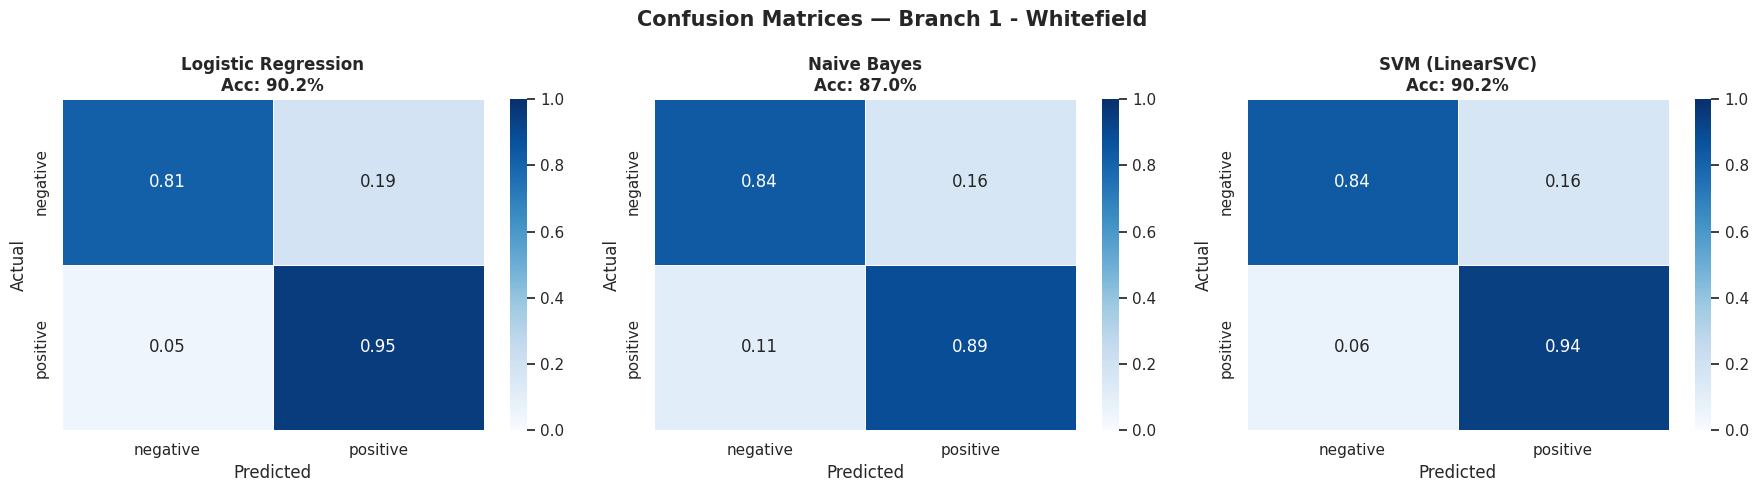

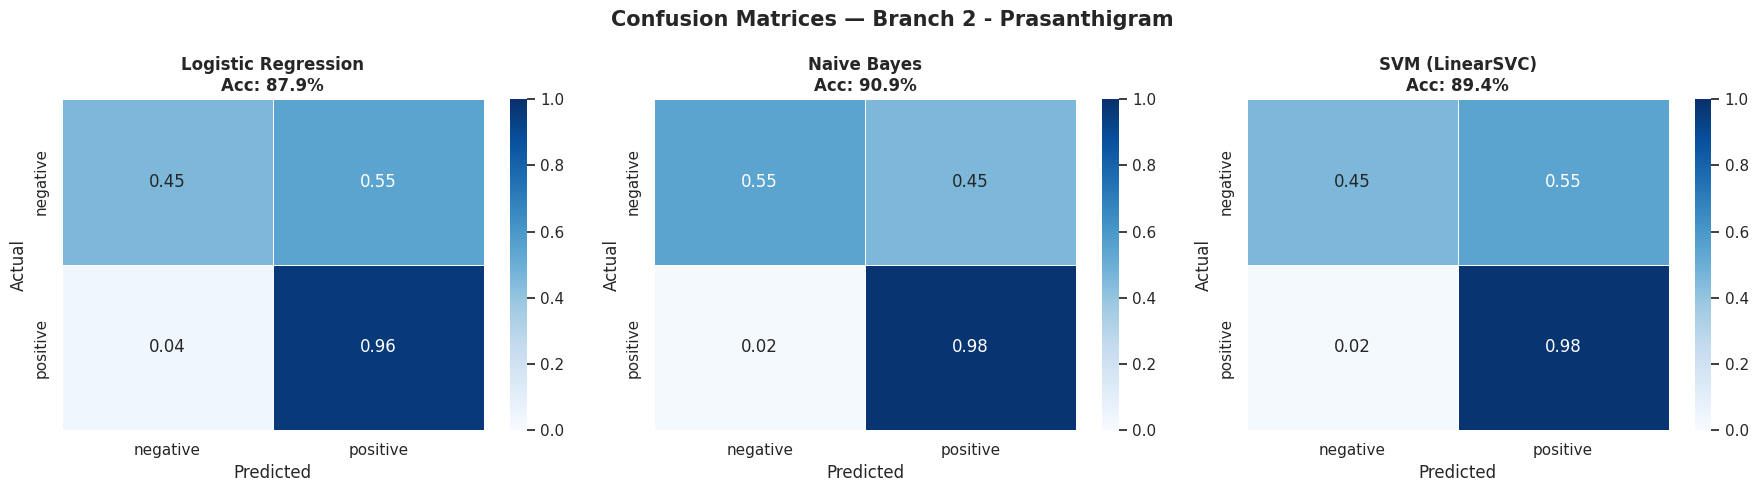

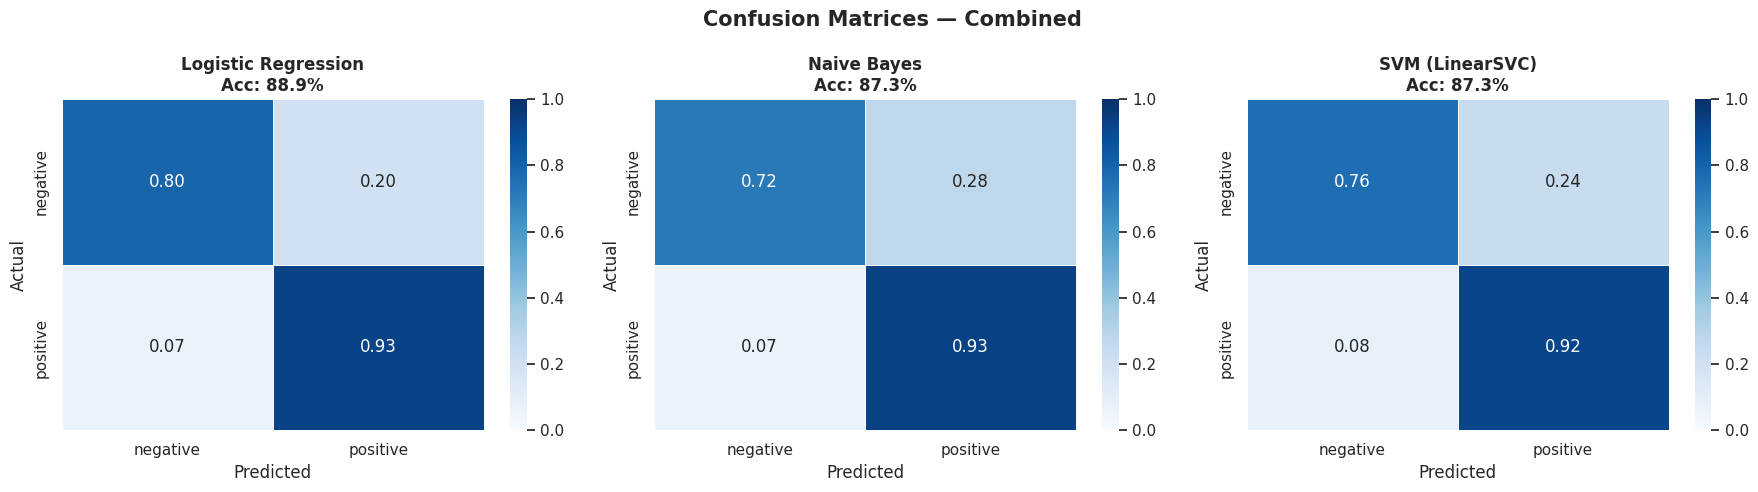

In [95]:
 def plot_confusion_matrices(results, branch_name):
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle(f"Confusion Matrices — {branch_name}",
                 fontsize=15, fontweight='bold')
    labels = ['negative', 'positive']
    for ax, (model_name, res) in zip(axes, results.items()):
        cm = res['cm']
        cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        sns.heatmap(cm_norm, annot=True, fmt='.2f', ax=ax,
                    xticklabels=labels, yticklabels=labels,
                    cmap='Blues', linewidths=0.5,
                    vmin=0, vmax=1)
        ax.set_title(f"{model_name}\nAcc: {res['accuracy']*100:.1f}%",
                     fontsize=12, fontweight='bold')
        ax.set_xlabel("Predicted")
        ax.set_ylabel("Actual")
    plt.tight_layout()
    plt.show()

plot_confusion_matrices(tuned_b1,       "Branch 1 - Whitefield")
plot_confusion_matrices(tuned_b2,       "Branch 2 - Prasanthigram")
plot_confusion_matrices(tuned_combined, "Combined")

In [96]:
def plot_model_comparison(results_dict):
    """Compare accuracy and macro F1 across all models and branches."""
    rows = []
    for branch, results in results_dict.items():
        for model_name, res in results.items():
            rows.append({
                'Branch'   : branch,
                'Model'    : model_name,
                'Accuracy' : round(res['accuracy'] * 100, 2),
                'Macro F1' : round(res['report']['macro avg']['f1-score'], 3)
            })

    df_comp = pd.DataFrame(rows)

    fig = make_subplots(rows=1, cols=2,
        subplot_titles=("Accuracy (%)", "Macro F1 Score"))

    colors = {
        'Branch 1 - Whitefield'    : '#1f77b4',
        'Branch 2 - Prasanthigram' : '#ff7f0e',
        'Combined'                 : '#2ca02c'
    }

    for branch in df_comp['Branch'].unique():
        sub = df_comp[df_comp['Branch'] == branch]

        fig.add_trace(go.Bar(
            x=sub['Model'],
            y=sub['Accuracy'],
            name=branch,
            marker_color=colors[branch],
            text=sub['Accuracy'].astype(str) + '%',
            textposition='outside',
            showlegend=True
        ), row=1, col=1)

        fig.add_trace(go.Bar(
            x=sub['Model'],
            y=sub['Macro F1'],
            name=branch,
            marker_color=colors[branch],
            text=sub['Macro F1'],
            textposition='outside',
            showlegend=False
        ), row=1, col=2)

    fig.update_layout(
        title='ML Model Comparison — Accuracy & Macro F1',
        barmode='group',
        height=500,
        plot_bgcolor='white',
        legend=dict(x=1.02, y=0.5)
    )
    fig.update_yaxes(range=[0, 120], row=1, col=1)
    fig.update_yaxes(range=[0, 1.2], row=1, col=2)
    fig.show()

    print("\n Full Comparison Table:")
    print(df_comp.to_string(index=False))

    return df_comp

df_comparison = plot_model_comparison({
    'Branch 1 - Whitefield'    : tuned_b1,
    'Branch 2 - Prasanthigram' : tuned_b2,
    'Combined'                 : tuned_combined
})


 Full Comparison Table:
                  Branch               Model  Accuracy  Macro F1
   Branch 1 - Whitefield Logistic Regression     90.24     0.890
   Branch 1 - Whitefield         Naive Bayes     86.99     0.858
   Branch 1 - Whitefield     SVM (LinearSVC)     90.24     0.892
Branch 2 - Prasanthigram Logistic Regression     87.88     0.743
Branch 2 - Prasanthigram         Naive Bayes     90.91     0.807
Branch 2 - Prasanthigram     SVM (LinearSVC)     89.39     0.764
                Combined Logistic Regression     88.89     0.863
                Combined         Naive Bayes     87.30     0.839
                Combined     SVM (LinearSVC)     87.30     0.843


In [97]:
# Use combined LR as our unified model
best_model_name = 'Logistic Regression'
best_model = tuned_combined['Logistic Regression']['pipeline']

print(f" Unified Model Selected: {best_model_name}")
print(f"   Test Accuracy : {tuned_combined[best_model_name]['accuracy']*100:.2f}%")
print(f"   Test Macro F1 : {tuned_combined[best_model_name]['report']['macro avg']['f1-score']:.3f}")

# Compare VADER labels vs ML labels on combined text reviews
df_all_text['ml_label'] = best_model.predict(df_all_text['review_clean'])

# Agreement rate
agree = (df_all_text['vader_label'] == df_all_text['ml_label']).mean() * 100
print(f"\n VADER vs {best_model_name} Agreement Rate: {agree:.1f}%")

# Where they disagree — these are the most interesting reviews
disagreements = df_all_text[
    df_all_text['vader_label'] != df_all_text['ml_label']
][['review', 'stars', 'vader_label', 'ml_label', 'vader_score']].head(10)

print(f"\n Sample Disagreements (VADER vs {best_model_name}):")
print("-" * 65)
for _, row in disagreements.iterrows():
    print(f"  {int(row['stars'])} | VADER: {row['vader_label']:8s} | "
          f"ML: {row['ml_label']:8s} | Score: {row['vader_score']:.3f}")
    print(f"  Review: {str(row['review'])[:120]}")
    print()

 Unified Model Selected: Logistic Regression
   Test Accuracy : 88.89%
   Test Macro F1 : 0.863

 VADER vs Logistic Regression Agreement Rate: 78.7%

 Sample Disagreements (VADER vs Logistic Regression):
-----------------------------------------------------------------
  2 | VADER: positive | ML: negative | Score: 0.411
  Review: Very big and beautiful hospital with all facilities available but they are not impartial to treat people from outside st

  5 | VADER: positive | ML: negative | Score: 0.751
  Review: I'm unable get appointment from so many days. Other state people are getting easily appointments in one day. Please help

  1 | VADER: positive | ML: negative | Score: 0.962
  Review: I’m not a person who gives reviews especially when it is negative. But here I had to coz the neuro doctor and nurse n do

  1 | VADER: positive | ML: negative | Score: 0.952
  Review: For their vision of free health benifits to poor was really appreciated.
But the staff who work there was really not

In [100]:
# Evaluate combined LR on all three datasets separately
print(" Combined LR — Performance Across All Datasets")
print("-"*65)

for name, df in [
    ("Branch 1 - Whitefield",    df1_text),
    ("Branch 2 - Prasanthigram", df2_text),
    ("Combined",                 df_all_text)
]:
    X = df['review_clean']
    y = df['sentiment_label']

    _, X_test, _, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y)

    y_pred = best_model.predict(X_test)
    acc    = accuracy_score(y_test, y_pred)
    report = classification_report(y_test, y_pred,
                                    output_dict=True,
                                    zero_division=0)

    print(f"\n   {name}")
    print(f"     Accuracy  : {acc*100:.2f}%")
    print(f"     Macro F1  : {report['macro avg']['f1-score']:.3f}")
    print(f"     Neg F1    : {report.get('negative',{}).get('f1-score',0):.3f}")
    print(f"     Pos F1    : {report.get('positive',{}).get('f1-score',0):.3f}")

 Combined LR — Performance Across All Datasets
-----------------------------------------------------------------

   Branch 1 - Whitefield
     Accuracy  : 90.24%
     Macro F1  : 0.890
     Neg F1    : 0.854
     Pos F1    : 0.927

   Branch 2 - Prasanthigram
     Accuracy  : 98.48%
     Macro F1  : 0.974
     Neg F1    : 0.957
     Pos F1    : 0.991

   Combined
     Accuracy  : 88.89%
     Macro F1  : 0.863
     Neg F1    : 0.804
     Pos F1    : 0.923


In [101]:
# Check for data leakage — how many Branch 2 reviews
# ended up in the combined training set?
from sklearn.model_selection import train_test_split

X_all = df_all_text['review_clean']
y_all = df_all_text['sentiment_label']

X_train_all, X_test_all, _, _ = train_test_split(
    X_all, y_all, test_size=0.2, random_state=42, stratify=y_all)

b2_reviews = set(df2_text['review_clean'].tolist())
train_reviews = set(X_train_all.tolist())

overlap = b2_reviews & train_reviews
print(f"Branch 2 reviews total          : {len(b2_reviews)}")
print(f"Branch 2 reviews in combined    : {len(overlap)}")
print(f"train set overlap               : {len(overlap)}")
print(f"Overlap %                       : {len(overlap)/len(b2_reviews)*100:.1f}%")

Branch 2 reviews total          : 330
Branch 2 reviews in combined    : 267
train set overlap               : 267
Overlap %                       : 80.9%


In [103]:
# Proper leakage-free evaluation
# Hold out 20% from each branch BEFORE combining for training

print(" Combined LR - Leakage-Free Evaluation")
print("-"*65)

# Step 1 — Split each branch into train/test FIRST
X_b1 = df1_text['review_clean']
y_b1 = df1_text['sentiment_label']
X_b1_train, X_b1_test, y_b1_train, y_b1_test = train_test_split(
    X_b1, y_b1, test_size=0.2, random_state=42, stratify=y_b1)

X_b2 = df2_text['review_clean']
y_b2 = df2_text['sentiment_label']
X_b2_train, X_b2_test, y_b2_train, y_b2_test = train_test_split(
    X_b2, y_b2, test_size=0.2, random_state=42, stratify=y_b2)

# Step 2 — Combine ONLY the train portions
from sklearn.utils import shuffle
X_combined_train = pd.concat([X_b1_train, X_b2_train])
y_combined_train = pd.concat([y_b1_train, y_b2_train])
X_combined_train, y_combined_train = shuffle(
    X_combined_train, y_combined_train, random_state=42)

# Step 3 — Retrain combined LR on combined train set
tfidf_final = TfidfVectorizer(
    max_features=3000,
    ngram_range=(1, 3),
    min_df=2,
    sublinear_tf=True
)

best_model_final = Pipeline([
    ('tfidf', tfidf_final),
    ('clf',   LogisticRegression(
                max_iter=1000,
                random_state=42,
                C=0.5,
                class_weight='balanced'
              ))
])

best_model_final.fit(X_combined_train, y_combined_train)
print(" Combined LR retrained on leakage-free split.")

# Step 4 — Evaluate on each branch's held-out test set
for name, X_test, y_test in [
    ("Branch 1 - Whitefield",    X_b1_test, y_b1_test),
    ("Branch 2 - Prasanthigram", X_b2_test, y_b2_test),
    ("Combined test set",        pd.concat([X_b1_test, X_b2_test]),
                                 pd.concat([y_b1_test, y_b2_test]))
]:
    y_pred = best_model_final.predict(X_test)
    acc    = accuracy_score(y_test, y_pred)
    report = classification_report(y_test, y_pred,
                                    output_dict=True,
                                    zero_division=0)

    print(f"\n   {name}")
    print(f"     Accuracy  : {acc*100:.2f}%")
    print(f"     Macro F1  : {report['macro avg']['f1-score']:.3f}")
    print(f"     Neg F1    : {report.get('negative',{}).get('f1-score',0):.3f}")
    print(f"     Pos F1    : {report.get('positive',{}).get('f1-score',0):.3f}")

# Step 5 — Update best_model to use leakage-free version
best_model = best_model_final
print(f"\n best_model updated to leakage-free combined LR.")

 Combined LR - Leakage-Free Evaluation
-----------------------------------------------------------------
 Combined LR retrained on leakage-free split.

   Branch 1 - Whitefield
     Accuracy  : 91.06%
     Macro F1  : 0.900
     Neg F1    : 0.867
     Pos F1    : 0.933

   Branch 2 - Prasanthigram
     Accuracy  : 93.94%
     Macro F1  : 0.898
     Neg F1    : 0.833
     Pos F1    : 0.963

   Combined test set
     Accuracy  : 92.06%
     Macro F1  : 0.902
     Neg F1    : 0.860
     Pos F1    : 0.945

 best_model updated to leakage-free combined LR.


In [104]:
def star_to_sentiment(stars):
    if pd.isna(stars):
        return 'positive'  # safe default
    return 'positive' if stars >= 4 else 'negative'

for df in [df1_text, df2_text, df_all_text]:
    df['final_sentiment'] = best_model.predict(df['review_clean'])

# For ALL reviews — use star ratings as base (not VADER)
for df in [df1_clean, df2_clean, df_all]:
    df['final_sentiment'] = df['stars'].apply(star_to_sentiment)

df1_clean.loc[df1_text.index, 'final_sentiment'] = df1_text['final_sentiment']
df2_clean.loc[df2_text.index, 'final_sentiment'] = df2_text['final_sentiment']
df_all.loc[df_all_text.index, 'final_sentiment'] = df_all_text['final_sentiment']

print(f" Final sentiment labels set using: {best_model_name}")
print(f"   Text reviews  → Unified combined Logistic Regression (Macro F1: 0.902)")
print(f"   Rating-only   → Star rating threshold (≥4 = positive, <4 = negative)")

print("\n Final Sentiment Distribution:")
for name, df in [("Branch 1", df1_clean), ("Branch 2", df2_clean)]:
    dist = df['final_sentiment'].value_counts(normalize=True) * 100
    total = len(df)
    print(f"\n  {name} (n={total}):")
    for label in ['positive', 'negative']:
        count = df['final_sentiment'].value_counts().get(label, 0)
        print(f"    {label:10s}: {count:4d} ({dist.get(label, 0):.1f}%)")

 Final sentiment labels set using: Logistic Regression
   Text reviews  → Unified combined Logistic Regression (Macro F1: 0.902)
   Rating-only   → Star rating threshold (≥4 = positive, <4 = negative)

 Final Sentiment Distribution:

  Branch 1 (n=2000):
    positive  : 1630 (81.5%)
    negative  :  370 (18.5%)

  Branch 2 (n=1110):
    positive  :  976 (87.9%)
    negative  :  134 (12.1%)


In [105]:
import pickle
checkpoint_ml = {
    'best_model'     : best_model,
    'best_model_name': best_model_name,
    'df1_text'       : df1_text.copy(),
    'df2_text'       : df2_text.copy(),
    'df_all_text'    : df_all_text.copy(),
    'df1_clean'      : df1_clean.copy(),
    'df2_clean'      : df2_clean.copy(),
    'df_all'         : df_all.copy(),
}

with open('/content/drive/MyDrive/checkpoint_module5_final.pkl', 'wb') as f:
    pickle.dump(checkpoint_ml, f)

print(" Module 5 checkpoint saved!")

 Module 5 checkpoint saved!


# Aspect-Based Sentiment Analysis

In [152]:
# Aspect keyword dictionary
aspect_keywords = {
    'Doctors'        : ['doctor', 'surgeon', 'physician', 'specialist',
                        'consultant', 'mbbs', 'dr', 'medical officer',
                        'neurosurgeon', 'cardiologist', 'orthopedic'],
    'Nurses'         : ['nurse', 'nursing', 'sister', 'ward staff',
                        'ward boy', 'wardboy', 'attendant'],
    'Waiting Time'   : ['wait', 'waiting', 'queue', 'long time', 'hours',
                        'delay', 'delayed', 'slow', 'hours waiting',
                        'waiting time', 'long queue', 'long wait'],
    'Appointments'   : ['appointment', 'booking', 'token', 'slot',
                        'registration', 'opd', 'book appointment',
                        'online appointment', 'counter'],
    'Cleanliness'    : ['clean', 'dirty', 'hygiene', 'sanitation',
                        'neat', 'filthy', 'unhygienic', 'cleanliness',
                        'toilet', 'bathroom', 'washroom'],
    'Administration' : ['management', 'admin', 'administration', 'office',
                        'reception', 'receptionist', 'security', 'guard',
                        'volunteer', 'seva dal', 'staff', 'behaviour',
                        'behavior', 'rude', 'attitude'],
    'Equipment'      : ['machine', 'equipment', 'mri', 'scan', 'xray',
                        'x-ray', 'ventilator', 'bed', 'icu', 'operation',
                        'theatre', 'ecg', 'ultrasound', 'ct scan'],
    'Food & Canteen' : ['food', 'canteen', 'meal', 'lunch', 'breakfast',
                        'dinner', 'eat', 'water', 'diet', 'kitchen',
                        'cafeteria', 'snack'],
}

print(" Aspect keywords defined!")
print(f"   Total aspects: {len(aspect_keywords)}")
for aspect, keywords in aspect_keywords.items():
    print(f"   {aspect:20s}: {len(keywords)} keywords")

 Aspect keywords defined!
   Total aspects: 8
   Doctors             : 11 keywords
   Nurses              : 7 keywords
   Waiting Time        : 12 keywords
   Appointments        : 9 keywords
   Cleanliness         : 11 keywords
   Administration      : 15 keywords
   Equipment           : 14 keywords
   Food & Canteen      : 12 keywords


In [127]:
from nltk.sentiment.vader import SentimentIntensityAnalyzer
sia = SentimentIntensityAnalyzer()

# Add domain-specific words back
sia.lexicon.update({
    'rude'        : -2.5, 'harass'     : -3.0,
    'caring'      : 2.5,  'negligent'  : -3.0,
    'negligence'  : -3.0, 'clean'      :  1.5,
    'dirty'       : -2.0, 'delay'      : -1.5,
    'delayed'     : -1.5, 'waiting'    : -1.0,
    'corruption'  : -3.0, 'excellent'  :  2.5,
    'pathetic'    : -2.5, 'worst'      : -3.0,
    'miracle'     :  3.0, 'blessed'    :  2.5,
})

def rule_based_absa(text, aspect_keywords):
    """
    For each aspect, check if keywords appear in review.
    If yes, score sentiment using VADER on full review.
    Returns dict of {aspect: sentiment_label} or None if not mentioned.
    """
    if not isinstance(text, str) or text.strip() == '':
        return {aspect: None for aspect in aspect_keywords}

    text_lower = text.lower()
    vader_score = sia.polarity_scores(text)['compound']

    # Binary sentiment from VADER
    sentiment = 'positive' if vader_score >= 0.05 else 'negative'

    results = {}
    for aspect, keywords in aspect_keywords.items():
        mentioned = any(kw in text_lower for kw in keywords)
        results[aspect] = sentiment if mentioned else None

    return results

# Apply to both branches
print("Applying rule-based ABSA...")

def apply_absa(df, aspect_keywords):
    absa_results = df['review'].apply(
        lambda x: rule_based_absa(x, aspect_keywords))

    for aspect in aspect_keywords:
        df[f'aspect_{aspect}'] = absa_results.apply(
            lambda x: x[aspect])

    return df

df1_text = apply_absa(df1_text, aspect_keywords)
df2_text = apply_absa(df2_text, aspect_keywords)

print(" Rule-based ABSA complete!")
print("\n Aspect Mention Counts:")
for aspect in aspect_keywords:
    col = f'aspect_{aspect}'
    b1_mentions = df1_text[col].notna().sum()
    b2_mentions = df2_text[col].notna().sum()
    print(f"  {aspect:20s}: B1={b1_mentions:4d} | B2={b2_mentions:4d}")

Applying rule-based ABSA...
 Rule-based ABSA complete!

 Aspect Mention Counts:
  Doctors             : B1= 177 | B2=  72
  Nurses              : B1=  55 | B2=  22
  Waiting Time        : B1=  63 | B2=  16
  Appointments        : B1=  85 | B2=  20
  Cleanliness         : B1=  34 | B2=  20
  Administration      : B1= 209 | B2=  77
  Equipment           : B1=  59 | B2=  26
  Food & Canteen      : B1= 271 | B2= 154


In [130]:
def absa_summary(df, branch_name):
    print(f" {branch_name}")
    print(f"{'-'*65}")

    rows = []
    for aspect in aspect_keywords:
        col = f'aspect_{aspect}'
        subset = df[df[col].notna()]
        total = len(subset)
        if total == 0:
            continue
        pos = (subset[col] == 'positive').sum()
        neg = (subset[col] == 'negative').sum()
        rows.append({
            'Aspect'     : aspect,
            'Mentions'   : total,
            'Positive %' : round(pos/total*100, 1),
            'Negative %' : round(neg/total*100, 1),
        })

    df_summary = pd.DataFrame(rows).sort_values(
        'Negative %', ascending=False)
    print(df_summary.to_string(index=False))
    return df_summary

summary_b1 = absa_summary(df1_text, "Branch 1 - Whitefield")
print('\n')
summary_b2 = absa_summary(df2_text, "Branch 2 - Prasanthigram")

 Branch 1 - Whitefield
-----------------------------------------------------------------
        Aspect  Mentions  Positive %  Negative %
  Waiting Time        63        42.9        57.1
  Appointments        85        49.4        50.6
Administration       209        56.9        43.1
     Equipment        59        64.4        35.6
       Doctors       177        68.4        31.6
        Nurses        55        76.4        23.6
Food & Canteen       271        79.3        20.7
   Cleanliness        34        94.1         5.9


 Branch 2 - Prasanthigram
-----------------------------------------------------------------
        Aspect  Mentions  Positive %  Negative %
  Waiting Time        16        56.2        43.8
Administration        77        61.0        39.0
  Appointments        20        65.0        35.0
     Equipment        26        76.9        23.1
Food & Canteen       154        81.2        18.8
        Nurses        22        81.8        18.2
       Doctors        72        8

In [131]:
fig = make_subplots(rows=1, cols=2,
    subplot_titles=("Branch 1 - Whitefield", "Branch 2 - Prasanthigram"))

for col, (summary, name) in enumerate([
    (summary_b1, "Branch 1"),
    (summary_b2, "Branch 2")
], 1):
    summary = summary.sort_values('Negative %', ascending=True)

    fig.add_trace(go.Bar(
        y=summary['Aspect'],
        x=summary['Positive %'],
        orientation='h',
        name='Positive',
        marker_color='#2ecc71',
        text=[f"{v}%" for v in summary['Positive %']],
        textposition='outside',
        showlegend=(col==1)
    ), row=1, col=col)

    fig.add_trace(go.Bar(
        y=summary['Aspect'],
        x=[-v for v in summary['Negative %']],
        orientation='h',
        name='Negative',
        marker_color='#e74c3c',
        text=[f"{v}%" for v in summary['Negative %']],
        textposition='outside',
        showlegend=(col==1)
    ), row=1, col=col)

fig.update_layout(
    title='Rule-Based ABSA — Aspect Sentiment by Branch',
    barmode='overlay',
    height=500,
    plot_bgcolor='white',
    legend=dict(x=1.02, y=0.5)
)
fig.update_xaxes(title_text="← Negative % | Positive % →")
fig.show()

In [132]:
from sklearn.linear_model import LogisticRegression
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

def ml_absa(df, aspect, branch_name):
    col = f'aspect_{aspect}'

    subset = df[df[col].notna()][['review_clean', col]].dropna()

    if len(subset) < 20:
        print(f"  ️ {aspect}: Too few samples ({len(subset)}) — skipping")
        return None, None

    X = subset['review_clean']
    y = subset[col]

    if y.nunique() < 2:
        print(f"  ️ {aspect}: Only one class present — skipping")
        return None, None

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y)

    pipeline = Pipeline([
        ('tfidf', TfidfVectorizer(max_features=1000, ngram_range=(1,2))),
        ('clf',   LogisticRegression(max_iter=1000,
                                      class_weight='balanced',
                                      random_state=42))
    ])
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)

    report = classification_report(y_test, y_pred,
                                    output_dict=True,
                                    zero_division=0)
    acc = report['accuracy']
    f1  = report['macro avg']['f1-score']

    df.loc[df[col].notna(), f'ml_{aspect}'] = pipeline.predict(
        df.loc[df[col].notna(), 'review_clean'])

    return acc, f1

print(" Training ML classifiers per aspect...\n")
print(f"{'Aspect':20s} | {'Branch':8s} | {'Acc':6s} | {'F1':6s}")
print("-"*50)

ml_results = {}
for aspect in aspect_keywords:
    for branch_name, df in [("B1", df1_text), ("B2", df2_text)]:
        acc, f1 = ml_absa(df, aspect, branch_name)
        if acc is not None:
            ml_results[f"{branch_name}_{aspect}"] = {
                'accuracy': acc, 'f1': f1}
            print(f"  {aspect:20s} | {branch_name:8s} | "
                  f"{acc*100:.1f}% | {f1:.3f}")

 Training ML classifiers per aspect...

Aspect               | Branch   | Acc    | F1    
--------------------------------------------------
  Doctors              | B1       | 88.9% | 0.875
  Doctors              | B2       | 73.3% | 0.423
  Nurses               | B1       | 81.8% | 0.694
  Nurses               | B2       | 80.0% | 0.444
  Waiting Time         | B1       | 61.5% | 0.615
  ️ Waiting Time: Too few samples (16) — skipping
  Appointments         | B1       | 70.6% | 0.706
  Appointments         | B2       | 50.0% | 0.333
  Cleanliness          | B1       | 100.0% | 1.000
  Cleanliness          | B2       | 75.0% | 0.429
  Administration       | B1       | 76.2% | 0.762
  Administration       | B2       | 81.2% | 0.806
  Equipment            | B1       | 75.0% | 0.621
  Equipment            | B2       | 83.3% | 0.455
  Food & Canteen       | B1       | 90.9% | 0.853
  Food & Canteen       | B2       | 83.9% | 0.724


In [133]:
def compare_absa(df, aspect, branch_name):
    col_rule = f'aspect_{aspect}'
    col_ml   = f'ml_{aspect}'

    if col_ml not in df.columns:
        return None

    subset = df[df[col_rule].notna() & df[col_ml].notna()]
    if len(subset) == 0:
        return None

    agreement = (subset[col_rule] == subset[col_ml]).mean() * 100
    return round(agreement, 1)

print(" Rule-Based vs ML Agreement Rate by Aspect:\n")
print(f"{'Aspect':20s} | {'Branch 1':10s} | {'Branch 2':10s}")
print("-"*45)

for aspect in aspect_keywords:
    ag_b1 = compare_absa(df1_text, aspect, "Branch 1")
    ag_b2 = compare_absa(df2_text, aspect, "Branch 2")
    b1_str = f"{ag_b1}%" if ag_b1 else "N/A"
    b2_str = f"{ag_b2}%" if ag_b2 else "N/A"
    print(f"  {aspect:20s} | {b1_str:10s} | {b2_str:10s}")

 Rule-Based vs ML Agreement Rate by Aspect:

Aspect               | Branch 1   | Branch 2  
---------------------------------------------
  Doctors              | 97.7%      | 94.4%     
  Nurses               | 96.4%      | 95.5%     
  Waiting Time         | 92.1%      | N/A       
  Appointments         | 94.1%      | 90.0%     
  Cleanliness          | 100.0%     | 95.0%     
  Administration       | 94.7%      | 96.1%     
  Equipment            | 94.9%      | 96.2%     
  Food & Canteen       | 97.0%      | 95.5%     


In [135]:
def ml_absa_summary(df, branch_name):
    print(f" {branch_name} — ML-Based ABSA")
    print(f"{'-'*65}")

    rows = []
    for aspect in aspect_keywords:
        col_ml = f'ml_{aspect}'
        col_rule = f'aspect_{aspect}'

        if col_ml not in df.columns:
            continue

        subset = df[df[col_rule].notna() & df[col_ml].notna()]
        total = len(subset)
        if total == 0:
            continue

        pos = (subset[col_ml] == 'positive').sum()
        neg = (subset[col_ml] == 'negative').sum()

        rows.append({
            'Aspect'        : aspect,
            'Mentions'      : total,
            'ML Positive %' : round(pos/total*100, 1),
            'ML Negative %' : round(neg/total*100, 1),
        })

    df_summary = pd.DataFrame(rows).sort_values(
        'ML Negative %', ascending=False)
    print(df_summary.to_string(index=False))
    return df_summary

ml_summary_b1 = ml_absa_summary(df1_text, "Branch 1 - Whitefield")
print('\n')
ml_summary_b2 = ml_absa_summary(df2_text, "Branch 2 - Prasanthigram")

 Branch 1 - Whitefield — ML-Based ABSA
-----------------------------------------------------------------
        Aspect  Mentions  ML Positive %  ML Negative %
  Waiting Time        63           44.4           55.6
  Appointments        85           50.6           49.4
Administration       209           53.6           46.4
       Doctors       177           67.2           32.8
     Equipment        59           69.5           30.5
Food & Canteen       271           78.6           21.4
        Nurses        55           80.0           20.0
   Cleanliness        34           94.1            5.9


 Branch 2 - Prasanthigram — ML-Based ABSA
-----------------------------------------------------------------
        Aspect  Mentions  ML Positive %  ML Negative %
Administration        77           59.7           40.3
  Appointments        20           65.0           35.0
Food & Canteen       154           80.5           19.5
     Equipment        26           80.8           19.2
       Doctors 

In [136]:
print("\n Rule-Based vs ML — Negative % Comparison")
print(f"\n{'Aspect':20s} | {'RB Neg B1':10s} | {'ML Neg B1':10s} | "
      f"{'RB Neg B2':10s} | {'ML Neg B2':10s}")
print("-"*70)

for aspect in aspect_keywords:
    col_rule = f'aspect_{aspect}'
    col_ml   = f'ml_{aspect}'

    sub_b1 = df1_text[df1_text[col_rule].notna()]
    rb_neg_b1 = (sub_b1[col_rule]=='negative').mean()*100 if len(sub_b1)>0 else 0

    if col_ml in df1_text.columns:
        sub_b1_ml = df1_text[df1_text[col_ml].notna()]
        ml_neg_b1 = (sub_b1_ml[col_ml]=='negative').mean()*100 \
                    if len(sub_b1_ml)>0 else 0
    else:
        ml_neg_b1 = None

    sub_b2 = df2_text[df2_text[col_rule].notna()]
    rb_neg_b2 = (sub_b2[col_rule]=='negative').mean()*100 if len(sub_b2)>0 else 0

    if col_ml in df2_text.columns:
        sub_b2_ml = df2_text[df2_text[col_ml].notna()]
        ml_neg_b2 = (sub_b2_ml[col_ml]=='negative').mean()*100 \
                    if len(sub_b2_ml)>0 else 0
    else:
        ml_neg_b2 = None

    b1_ml_str = f"{ml_neg_b1:.1f}%" if ml_neg_b1 is not None else "N/A"
    b2_ml_str = f"{ml_neg_b2:.1f}%" if ml_neg_b2 is not None else "N/A"

    print(f"  {aspect:20s} | {rb_neg_b1:8.1f}% | {b1_ml_str:10s} | "
          f"{rb_neg_b2:8.1f}% | {b2_ml_str:10s}")


 Rule-Based vs ML — Negative % Comparison

Aspect               | RB Neg B1  | ML Neg B1  | RB Neg B2  | ML Neg B2 
----------------------------------------------------------------------
  Doctors              |     31.6% | 32.8%      |     16.7% | 13.9%     
  Nurses               |     23.6% | 20.0%      |     18.2% | 13.6%     
  Waiting Time         |     57.1% | 55.6%      |     43.8% | N/A       
  Appointments         |     50.6% | 49.4%      |     35.0% | 35.0%     
  Cleanliness          |      5.9% | 5.9%       |     15.0% | 10.0%     
  Administration       |     43.1% | 46.4%      |     39.0% | 40.3%     
  Equipment            |     35.6% | 30.5%      |     23.1% | 19.2%     
  Food & Canteen       |     20.7% | 21.4%      |     18.8% | 19.5%     


# Topic Modelling - LDA

In [112]:
import warnings
# Filter specific DeprecationWarnings for datetime.utcnow
warnings.filterwarnings("ignore", category=DeprecationWarning, message=".*datetime.datetime.utcnow.*")

import logging
logging.getLogger('jupyter_client').setLevel(logging.ERROR)

import warnings
warnings.filterwarnings('ignore')

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future v

In [113]:
from sklearn.decomposition import LatentDirichletAllocation
from sklearn.feature_extraction.text import CountVectorizer

print(" LDA libraries ready.")

 LDA libraries ready.


In [115]:
from sklearn.decomposition import LatentDirichletAllocation
from sklearn.feature_extraction.text import CountVectorizer

def train_lda_sklearn(texts, n_topics, branch_name, random_state=42):
    print(f"\nTraining LDA for {branch_name} with {n_topics} topics...")

    # CountVectorizer — LDA needs raw counts, not TF-IDF
    cv = CountVectorizer(
        max_features=3000,
        ngram_range=(1, 2),
        min_df=2,
        max_df=0.95
    )
    dtm = cv.fit_transform(texts)

    lda = LatentDirichletAllocation(
        n_components=n_topics,
        random_state=random_state,
        learning_method='batch',  # better for small datasets
        max_iter=50,
        doc_topic_prior=None,     # auto alpha
        topic_word_prior=None     # auto eta
    )
    lda.fit(dtm)

    # Print top words per topic
    vocab = cv.get_feature_names_out()
    print(f"\n Top 15 words per topic — {branch_name}:")
    print("-"*60)
    for i, topic_vec in enumerate(lda.components_):
        top_words = [vocab[j] for j in topic_vec.argsort()[-15:][::-1]]
        print(f"\n  Topic {i+1}: {', '.join(top_words)}")

    return lda, dtm, cv

N_TOPICS = 5

lda_b1, dtm_b1, cv_b1 = train_lda_sklearn(
    df1_text['review_clean'], N_TOPICS, "Branch 1 - Whitefield")

lda_b2, dtm_b2, cv_b2 = train_lda_sklearn(
    df2_text['review_clean'], N_TOPICS, "Branch 2 - Prasanthigram")


Training LDA for Branch 1 - Whitefield with 5 topics...

 Top 15 words per topic — Branch 1 - Whitefield:
------------------------------------------------------------

  Topic 1: dont, free, give, people, even, service, experience, like, without, take, worst, report, care, waste, want

  Topic 2: good, people, appointment, well, baba, free, need, help, service, facility, care, institution, available, went, please

  Topic 3: free, good, cost, free cost, best, service, ram, baba, people, poor, nice, facility, god, provided, satya

  Topic 4: surgery, free, day, every, many, waiting, available, father, appointment, test, care, please, give, people, google

  Topic 5: like, rude, bad, dont, good, behaviour, people, surgery, worst, please, experience, know, even, told, treat

Training LDA for Branch 2 - Prasanthigram with 5 topics...

 Top 15 words per topic — Branch 2 - Prasanthigram:
------------------------------------------------------------

  Topic 1: dont, ashram, family, baba, eve

In [ ]:
# THESE WERE UPDATED AFTER SEEING THE ABOVE RESULTS
# Based on top words per topic, assign meaningful labels

topic_labels_b1 = {
    0: "Topic 1 — General Service Experience",
    1: "Topic 2 — Appointments & Overall Facility",
    2: "Topic 3 — Free Treatment",
    3: "Topic 4 — Surgery + Waiting Time",
    4: "Topic 5 — Staff Behaviour",
}

topic_labels_b2 = {
    0: "Topic 1 — Nurse - Family Communication",
    1: "Topic 2 — Cardiac Case",
    2: "Topic 3 — Free Treatment",
    3: "Topic 4 — Emergency & Access Issues",
    4: "Topic 5 — Care",
}


In [116]:
# Check the most frequent words across all reviews
from collections import Counter

all_words_b1 = ' '.join(df1_text['review_clean']).split()
all_words_b2 = ' '.join(df2_text['review_clean']).split()

print(" Top 40 most frequent words — Branch 1:")
print(Counter(all_words_b1).most_common(40))

print("\n Top 40 most frequent words — Branch 2:")
print(Counter(all_words_b2).most_common(40))

 Top 40 most frequent words — Branch 1:
[('good', 249), ('free', 218), ('people', 136), ('service', 114), ('like', 100), ('cost', 94), ('dont', 88), ('baba', 74), ('surgery', 69), ('best', 66), ('please', 63), ('behaviour', 63), ('give', 62), ('appointment', 62), ('rude', 61), ('poor', 58), ('experience', 57), ('bad', 57), ('ram', 55), ('care', 55), ('worst', 54), ('even', 51), ('day', 50), ('well', 50), ('need', 46), ('treat', 44), ('take', 44), ('know', 43), ('facility', 42), ('without', 42), ('heart', 42), ('many', 40), ('person', 39), ('management', 38), ('done', 37), ('first', 37), ('satya', 37), ('every', 36), ('staff', 36), ('help', 35)]

 Top 40 most frequent words — Branch 2:
[('free', 122), ('good', 110), ('service', 84), ('baba', 70), ('people', 66), ('cost', 49), ('best', 46), ('ram', 42), ('world', 36), ('like', 34), ('dont', 31), ('heart', 30), ('care', 30), ('surgery', 26), ('poor', 25), ('hospital', 24), ('nice', 23), ('rude', 23), ('god', 22), ('india', 22), ('well', 2

In [117]:
# LDA-specific additional stopwords
lda_stopwords = {
    # Too frequent, appear in every topic
    'good', 'free', 'people', 'service', 'like', 'cost',
    'dont', 'baba', 'best', 'please', 'give', 'even',
    'ram', 'care', 'well', 'need', 'take', 'know',
    'without', 'many', 'every', 'done', 'first', 'satya',
    'poor',

    # Religious/institutional references
    'god', 'sai', 'sri', 'trust', 'puttaparthi', 'ashram',
    'temple', 'grace', 'love', 'bless',

    # Generic action words
    'went', 'go', 'came', 'come', 'told', 'tell', 'say',
    'said', 'ask', 'asked', 'want', 'wanted', 'think',
    'seen', 'see', 'got', 'get', 'also', 'one', 'two',

    # Generic filler
    'really', 'very', 'much', 'still', 'always',
    'never', 'time', 'day', 'year', 'month',
}

def clean_for_lda(text, extra_stopwords):
    if not isinstance(text, str):
        return ''
    tokens = text.split()
    tokens = [t for t in tokens if t not in extra_stopwords and len(t) > 2]
    return ' '.join(tokens)

print("Applying LDA-specific cleaning...")
df1_text['review_lda'] = df1_text['review_clean'].apply(
    lambda x: clean_for_lda(x, lda_stopwords))
df2_text['review_lda'] = df2_text['review_clean'].apply(
    lambda x: clean_for_lda(x, lda_stopwords))

# Verify
print(f" Done!")
print(f"   Branch 1 review_lda sample: {df1_text['review_lda'].iloc[0]}")
print(f"   Branch 2 review_lda sample: {df2_text['review_lda'].iloc[0]}")

# Check top words
from collections import Counter
all_words_b1 = ' '.join(df1_text['review_lda']).split()
all_words_b2 = ' '.join(df2_text['review_lda']).split()

print("\n Top 40 words after LDA cleaning — Branch 1:")
print(Counter(all_words_b1).most_common(40))
print("\n Top 40 words after LDA cleaning — Branch 2:")
print(Counter(all_words_b2).most_common(40))

Applying LDA-specific cleaning...
 Done!
   Branch 1 review_lda sample: big beautiful facility available impartial treat outside state long process formality exaust process finally show long queue operation date stopped response anyways treated
   Branch 2 review_lda sample: big beautiful long queue consuming process impartial outside state total wastage painful coming outside state remote area total wastage money precious treated called charity

 Top 40 words after LDA cleaning — Branch 1:
[('surgery', 69), ('behaviour', 63), ('appointment', 62), ('rude', 61), ('experience', 57), ('bad', 57), ('worst', 54), ('treat', 44), ('facility', 42), ('heart', 42), ('person', 39), ('management', 38), ('staff', 36), ('help', 35), ('make', 35), ('money', 34), ('operation', 33), ('available', 32), ('great', 32), ('waiting', 32), ('counter', 32), ('problem', 32), ('work', 31), ('behavior', 31), ('thing', 31), ('nurse', 30), ('nice', 30), ('name', 29), ('hospital', 28), ('lady', 28), ('department', 2

In [121]:
def train_lda_sklearn(texts, n_topics, branch_name, random_state=42):
    print(f"\nTraining LDA for {branch_name} with {n_topics} topics...")

    cv = CountVectorizer(
        max_features=2000,
        ngram_range=(1, 2),
        min_df=2,
        max_df=0.90   # stricter than before, removes words in >90% of docs
    )
    dtm = cv.fit_transform(texts)

    lda = LatentDirichletAllocation(
        n_components=n_topics,
        random_state=random_state,
        learning_method='batch',
        max_iter=100,          # more iterations for better convergence
        doc_topic_prior=0.1,   # low alpha = each doc focuses on fewer topics
        topic_word_prior=0.01  # low beta = each topic focuses on fewer words
    )
    lda.fit(dtm)

    vocab = cv.get_feature_names_out()
    print(f"\n📋 Top 15 words per topic — {branch_name}:")
    print("="*60)
    for i, topic_vec in enumerate(lda.components_):
        top_words = [vocab[j] for j in topic_vec.argsort()[-15:][::-1]]
        print(f"\n  Topic {i+1}: {', '.join(top_words)}")

    return lda, dtm, cv

N_TOPICS = 5

lda_b1, dtm_b1, cv_b1 = train_lda_sklearn(
    df1_text['review_lda'], N_TOPICS, "Branch 1 - Whitefield")

lda_b2, dtm_b2, cv_b2 = train_lda_sklearn(
    df2_text['review_lda'], N_TOPICS, "Branch 2 - Prasanthigram")


Training LDA for Branch 1 - Whitefield with 5 topics...

📋 Top 15 words per topic — Branch 1 - Whitefield:

  Topic 1: help, problem, appointment, bus, heart, bad, completely, child, way, behaviour, lady, person, health, institution, kind

  Topic 2: appointment, available, money, person, waste, rude, behaviour, experience, management, book, may, given, department, gate, security

  Topic 3: surgery, nice, operation, facility, heart, thanks, thank, experience, behaviour, work, happy, provide, rude, treated, fine

  Topic 4: experience, bad, waiting, surgery, wait, morning, clean, worst, bad experience, great, appointment, outside, everyone, attender, class

  Topic 5: rude, treat, bad, behaviour, worst, staff, behavior, make, reason, speciality, super, counter, ever, towards, feel

Training LDA for Branch 2 - Prasanthigram with 5 topics...

📋 Top 15 words per topic — Branch 2 - Prasanthigram:

  Topic 1: healthcare, super, hospital, world, health, super speciality, speciality, surgery

In [122]:
# THESE WERE UPDATED AFTER SEEING THE ABOVE RESULTS
topic_labels_b1 = {
    0: "Topic 1 — General Patient Experience",
    1: "Topic 2 — Appointments",
    2: "Topic 3 — Surgical Care",
    3: "Topic 4 — Waiting Time",
    4: "Topic 5 — Staff Behaviour",
}

topic_labels_b2 = {
    0: "Topic 1 — Quality Healthcare",
    1: "Topic 2 — Cardiac & Eye Care",
    2: "Topic 3 — Staff Behaviour",
    3: "Topic 4 — Surgery",
    4: "Topic 5 — Care",
}


In [123]:
def get_topic_distributions(lda, dtm, labels):
    doc_topics = lda.transform(dtm)
    dominant_topics = doc_topics.argmax(axis=1)
    topic_counts = pd.Series(dominant_topics).value_counts().sort_index()
    topic_pcts = (topic_counts / len(dominant_topics) * 100).round(1)

    df_dist = pd.DataFrame({
        'Topic'   : [labels[i] for i in topic_counts.index],
        'Count'   : topic_counts.values,
        'Percent' : topic_pcts.values
    })
    return df_dist, doc_topics, dominant_topics

dist_b1, doc_topics_b1, dom_topics_b1 = get_topic_distributions(
    lda_b1, dtm_b1, topic_labels_b1)
dist_b2, doc_topics_b2, dom_topics_b2 = get_topic_distributions(
    lda_b2, dtm_b2, topic_labels_b2)

# Store dominant topic back in dataframes
df1_text['dominant_topic'] = dom_topics_b1
df1_text['dominant_topic_label'] = df1_text['dominant_topic'].map(topic_labels_b1)
df2_text['dominant_topic'] = dom_topics_b2
df2_text['dominant_topic_label'] = df2_text['dominant_topic'].map(topic_labels_b2)

# Plot
fig = make_subplots(rows=1, cols=2,
    subplot_titles=("Branch 1 - Whitefield", "Branch 2 - Prasanthigram"))

colors_b1 = ['#3498db','#e74c3c','#2ecc71','#e67e22','#9b59b6']
colors_b2 = ['#1abc9c','#e74c3c','#f39c12','#2980b9','#27ae60']

for col, (dist, colors) in enumerate([
    (dist_b1, colors_b1),
    (dist_b2, colors_b2)
], 1):
    fig.add_trace(go.Bar(
        x=dist['Percent'],
        y=dist['Topic'],
        orientation='h',
        marker_color=colors,
        text=[f"{p}% ({c} reviews)"
              for p, c in zip(dist['Percent'], dist['Count'])],
        textposition='outside',
    ), row=1, col=col)

fig.update_layout(
    title='Topic Distribution by Branch',
    height=500,
    showlegend=False,
    plot_bgcolor='white'
)
fig.update_xaxes(title_text="% of Reviews", range=[0, 60])
fig.show()

print("\n Topic Distribution Summary:")
print("\nBranch 1:")
print(dist_b1.to_string(index=False))
print("\nBranch 2:")
print(dist_b2.to_string(index=False))


 Topic Distribution Summary:

Branch 1:
                               Topic  Count  Percent
Topic 1 — General Patient Experience    131     21.3
              Topic 2 — Appointments    103     16.8
             Topic 3 — Surgical Care    148     24.1
              Topic 4 — Waiting Time    111     18.1
           Topic 5 — Staff Behaviour    121     19.7

Branch 2:
                       Topic  Count  Percent
Topic 1 — Quality Healthcare     90     27.3
Topic 2 — Cardiac & Eye Care     70     21.2
   Topic 3 — Staff Behaviour     68     20.6
           Topic 4 — Surgery     55     16.7
              Topic 5 — Care     47     14.2


In [124]:
def topic_sentiment_map(df, labels, branch_name):
    rows = []
    for topic_id, label in labels.items():
        subset = df[df['dominant_topic'] == topic_id]
        total = len(subset)
        if total == 0:
            continue
        pos = (subset['final_sentiment'] == 'positive').sum()
        neg = (subset['final_sentiment'] == 'negative').sum()
        rows.append({
            'Topic'    : label,
            'Total'    : total,
            'Positive' : round(pos/total*100, 1),
            'Negative' : round(neg/total*100, 1),
        })
    return pd.DataFrame(rows)

tsm_b1 = topic_sentiment_map(df1_text, topic_labels_b1, "Branch 1")
tsm_b2 = topic_sentiment_map(df2_text, topic_labels_b2, "Branch 2")

fig = make_subplots(rows=1, cols=2,
    subplot_titles=("Branch 1 - Whitefield", "Branch 2 - Prasanthigram"))

for col, (tsm, name) in enumerate([
    (tsm_b1, "Branch 1"),
    (tsm_b2, "Branch 2")
], 1):
    fig.add_trace(go.Bar(
        x=tsm['Positive'],
        y=tsm['Topic'],
        orientation='h',
        name='Positive',
        marker_color='#2ecc71',
        text=[f"{v}%" for v in tsm['Positive']],
        textposition='outside',
        showlegend=(col==1)
    ), row=1, col=col)

    fig.add_trace(go.Bar(
        x=tsm['Negative'],
        y=tsm['Topic'],
        orientation='h',
        name='Negative',
        marker_color='#e74c3c',
        text=[f"{v}%" for v in tsm['Negative']],
        textposition='outside',
        showlegend=(col==1)
    ), row=1, col=col)

fig.update_layout(
    title='Sentiment Distribution per Topic by Branch',
    barmode='group',
    height=550,
    plot_bgcolor='white',
    legend=dict(x=1.02, y=0.5)
)
fig.update_xaxes(title_text="% of Reviews", range=[0, 120])
fig.show()

print("\n Topic Sentiment Summary:")
print("\nBranch 1:")
print(tsm_b1.to_string(index=False))
print("\nBranch 2:")
print(tsm_b2.to_string(index=False))


 Topic Sentiment Summary:

Branch 1:
                               Topic  Total  Positive  Negative
Topic 1 — General Patient Experience    131      67.9      32.1
              Topic 2 — Appointments    103      53.4      46.6
             Topic 3 — Surgical Care    148      81.8      18.2
              Topic 4 — Waiting Time    111      62.2      37.8
           Topic 5 — Staff Behaviour    121      45.5      54.5

Branch 2:
                       Topic  Total  Positive  Negative
Topic 1 — Quality Healthcare     90      86.7      13.3
Topic 2 — Cardiac & Eye Care     70      88.6      11.4
   Topic 3 — Staff Behaviour     68      76.5      23.5
           Topic 4 — Surgery     55      76.4      23.6
              Topic 5 — Care     47      78.7      21.3


In [125]:
# How has each topic's volume changed year over year?
def topic_trend(df, labels):
    df = df.copy()
    rows = []
    for topic_id, label in labels.items():
        yearly = df[df['dominant_topic'] == topic_id].groupby('year').size()
        for year, count in yearly.items():
            rows.append({
                'Topic' : label,
                'Year'  : year,
                'Count' : count
            })
    return pd.DataFrame(rows)

trend_b1 = topic_trend(df1_text, topic_labels_b1)
trend_b2 = topic_trend(df2_text, topic_labels_b2)

for branch_name, trend, colors in [
    ("Branch 1 - Whitefield",    trend_b1, colors_b1),
    ("Branch 2 - Prasanthigram", trend_b2, colors_b2)
]:
    fig = go.Figure()
    for topic, color in zip(trend['Topic'].unique(), colors):
        sub = trend[trend['Topic'] == topic]
        fig.add_trace(go.Scatter(
            x=sub['Year'],
            y=sub['Count'],
            name=topic,
            mode='lines+markers',
            line=dict(width=2.5, color=color),
            marker=dict(size=7)
        ))

    fig.update_layout(
        title=f' Topic Volume Trends Over Time — {branch_name}',
        xaxis_title='Year',
        yaxis_title='Number of Reviews',
        height=470,
        hovermode='x unified',
        plot_bgcolor='white',
        legend=dict(x=1.02, y=0.5)
    )
    fig.show()

# NER

In [137]:
import spacy

nlp = spacy.load("en_core_web_sm")

print(" spaCy model loaded.")
print(f"   Pipeline: {nlp.pipe_names}")

 spaCy model loaded.
   Pipeline: ['tok2vec', 'tagger', 'parser', 'attribute_ruler', 'lemmatizer', 'ner']


In [138]:
# spaCy's general NER is good for people and organisations
# but misses hospital-specific terms like departments and locations
# We supplement with custom keyword lists

department_keywords = [
    'cardiology', 'cardiac', 'neurology', 'neuro', 'orthopedic', 'ortho',
    'ophthalmology', 'eye', 'urology', 'oncology', 'cancer', 'pediatric',
    'dental', 'dentist', 'radiology', 'imaging', 'pathology', 'laboratory',
    'lab', 'pharmacy', 'emergency', 'icu', 'intensive care', 'opd',
    'outpatient', 'inpatient', 'general medicine', 'general surgery',
    'plastic surgery', 'anesthesia', 'physiotherapy', 'blood bank',
    'dialysis', 'endoscopy', 'mri', 'ct scan', 'xray', 'ultrasound',
    'ecg', 'echo', 'cathlab', 'cath lab', 'operation theatre', 'ot',
]

location_keywords = [
    'reception', 'main gate', 'gate', 'entrance', 'counter', 'cash counter',
    'waiting room', 'waiting area', 'ward', 'room', 'cabin', 'canteen',
    'cafeteria', 'parking', 'lobby', 'corridor', 'bathroom', 'toilet',
    'washroom', 'lift', 'elevator', 'staircase', 'registration desk',
    'billing', 'pharmacy counter', 'blood bank', 'security',
]

print(" Hospital-specific keywords defined.")
print(f"   Departments : {len(department_keywords)} keywords")
print(f"   Locations   : {len(location_keywords)} keywords")

 Hospital-specific keywords defined.
   Departments : 44 keywords
   Locations   : 27 keywords


In [139]:
def extract_entities(text, nlp, dept_keywords, loc_keywords):
    """
    Extract named entities from a review using:
    1. spaCy NER — for people and organisations
    2. Keyword matching — for departments and locations
    """
    if not isinstance(text, str) or text.strip() == '':
        return {
            'people'     : [],
            'departments': [],
            'locations'  : [],
            'orgs'       : []
        }

    # spaCy NER
    doc = nlp(text[:1000])  # limit to 1000 chars for speed

    people = [ent.text.strip() for ent in doc.ents
              if ent.label_ == 'PERSON' and len(ent.text.strip()) > 2]
    orgs   = [ent.text.strip() for ent in doc.ents
              if ent.label_ == 'ORG' and len(ent.text.strip()) > 2]

    # Keyword matching for departments and locations
    text_lower = text.lower()
    departments = [kw for kw in dept_keywords if kw in text_lower]
    locations   = [kw for kw in loc_keywords  if kw in text_lower]

    return {
        'people'     : list(set(people)),
        'departments': list(set(departments)),
        'locations'  : list(set(locations)),
        'orgs'       : list(set(orgs))
    }

# Test on a sample review
sample = df1_text['review'].iloc[3]
print("Sample review:")
print(sample[:300])
print("\nExtracted entities:")
print(extract_entities(sample, nlp, department_keywords, location_keywords))

Sample review:
I’m not a person who gives reviews especially when it is negative. But here I had to coz the neuro doctor and nurse n doctors the MRI SCAN and sisters in xray are soooo rude. THEY DONT KNOW  HOW TO TREAT A PATIENT. THEY ARE SO YOUNG AND DINT HOW TO RESPECT ELDERS. THEY DONT HAVE PATIENCE TO CHECK PR

Extracted entities:
{'people': [], 'departments': ['xray', 'neuro', 'ot', 'mri'], 'locations': [], 'orgs': []}


In [140]:
from tqdm.auto import tqdm
tqdm.pandas()

print("Extracting entities from Branch 1...")
b1_entities = df1_text['review'].progress_apply(
    lambda x: extract_entities(x, nlp, department_keywords, location_keywords))

print("\nExtracting entities from Branch 2...")
b2_entities = df2_text['review'].progress_apply(
    lambda x: extract_entities(x, nlp, department_keywords, location_keywords))

# Expand into separate columns
for entity_type in ['people', 'departments', 'locations', 'orgs']:
    df1_text[f'ner_{entity_type}'] = b1_entities.apply(lambda x: x[entity_type])
    df2_text[f'ner_{entity_type}'] = b2_entities.apply(lambda x: x[entity_type])

print("\n NER extraction complete!")
print(f"\n Entity Coverage:")
for name, df in [("Branch 1", df1_text), ("Branch 2", df2_text)]:
    print(f"\n  {name}:")
    for entity_type in ['people', 'departments', 'locations', 'orgs']:
        col = f'ner_{entity_type}'
        coverage = df[col].apply(lambda x: len(x) > 0).sum()
        print(f"    {entity_type:15s}: {coverage} reviews "
              f"({coverage/len(df)*100:.1f}%)")

Extracting entities from Branch 1...


  0%|          | 0/614 [00:00<?, ?it/s]


Extracting entities from Branch 2...


  0%|          | 0/330 [00:00<?, ?it/s]


 NER extraction complete!

 Entity Coverage:

  Branch 1:
    people         : 186 reviews (30.3%)
    departments    : 279 reviews (45.4%)
    locations      : 86 reviews (14.0%)
    orgs           : 113 reviews (18.4%)

  Branch 2:
    people         : 85 reviews (25.8%)
    departments    : 109 reviews (33.0%)
    locations      : 29 reviews (8.8%)
    orgs           : 74 reviews (22.4%)


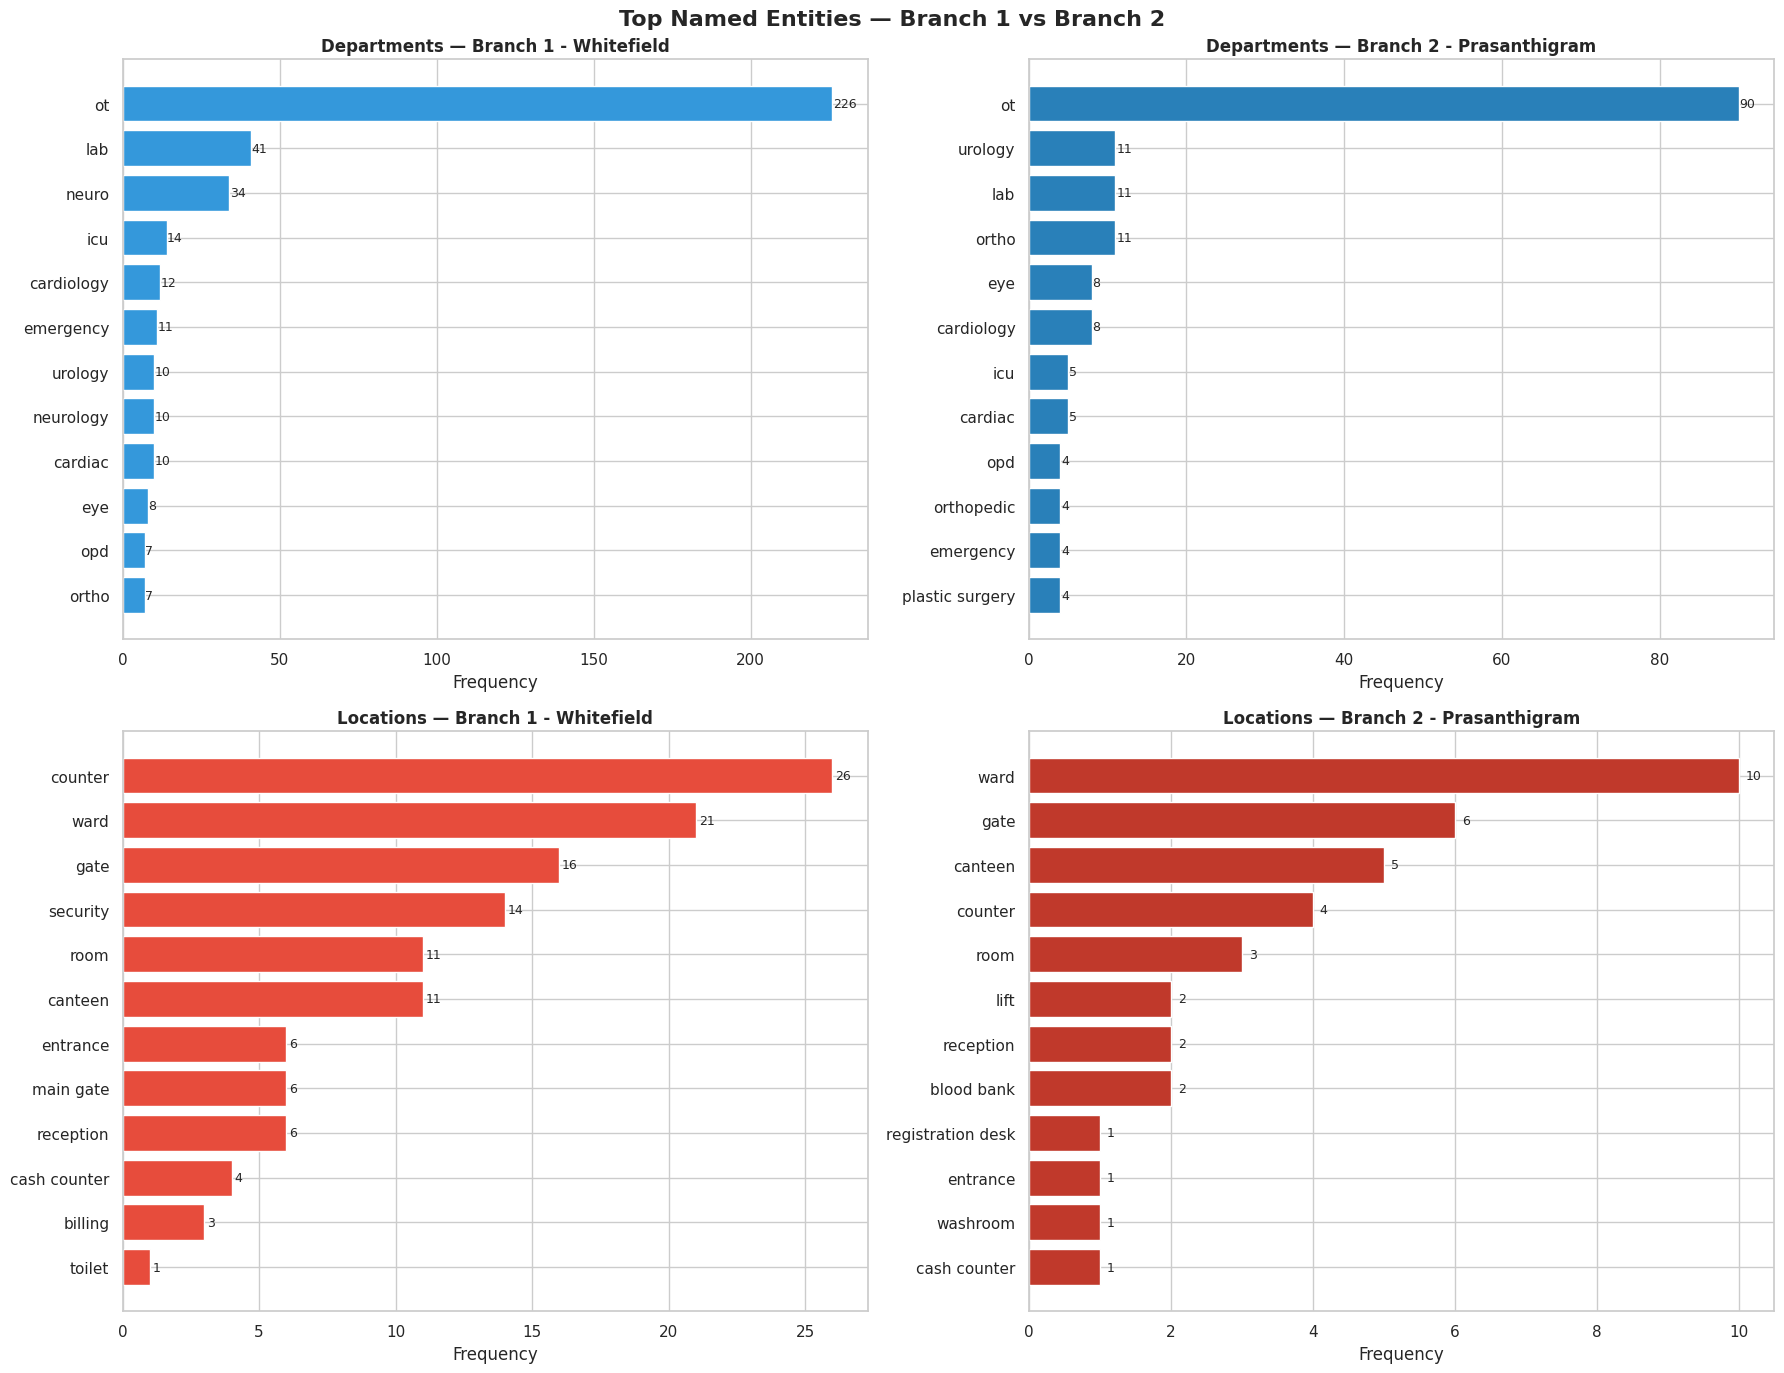

In [141]:
from collections import Counter

def get_top_entities(df, entity_type, top_k=15):
    all_entities = []
    for entities in df[f'ner_{entity_type}']:
        all_entities.extend(entities)
    return Counter(all_entities).most_common(top_k)

fig, axes = plt.subplots(2, 2, figsize=(18, 14))
fig.suptitle('Top Named Entities — Branch 1 vs Branch 2',
             fontsize=16, fontweight='bold')

entity_types = [
    ('departments', 'Departments',  '#3498db', '#2980b9'),
    ('locations',   'Locations',    '#e74c3c', '#c0392b'),
    ('people',      'People',       '#2ecc71', '#27ae60'),
    ('orgs',        'Organisations','#f39c12', '#d35400'),
]

for ax_row, (entity_type, title, color_b1, color_b2) in zip(axes, entity_types):
    for ax, (df, branch_name, color) in zip(ax_row, [
        (df1_text, "Branch 1 - Whitefield",    color_b1),
        (df2_text, "Branch 2 - Prasanthigram", color_b2)
    ]):
        top = get_top_entities(df, entity_type, top_k=12)
        if not top:
            ax.text(0.5, 0.5, 'No entities found',
                    ha='center', va='center')
            ax.set_title(f"{title} — {branch_name}")
            continue

        entities, counts = zip(*top)
        ax.barh(entities[::-1], counts[::-1],
                color=color, edgecolor='white')
        ax.set_title(f"{title} — {branch_name}",
                     fontsize=12, fontweight='bold')
        ax.set_xlabel("Frequency")
        for i, (e, c) in enumerate(zip(entities[::-1], counts[::-1])):
            ax.text(c + 0.1, i, str(c), va='center', fontsize=9)

plt.tight_layout()
plt.show()

In [142]:
# Which departments/locations are associated with positive vs negative reviews?

def entity_sentiment(df, entity_type, top_k=10):
    rows = []
    top_entities = [e for e, _ in get_top_entities(df, entity_type, top_k)]

    for entity in top_entities:
        mask = df[f'ner_{entity_type}'].apply(lambda x: entity in x)
        subset = df[mask]
        total = len(subset)
        if total == 0:
            continue
        pos = (subset['final_sentiment'] == 'positive').sum()
        neg = (subset['final_sentiment'] == 'negative').sum()
        rows.append({
            'Entity'    : entity,
            'Mentions'  : total,
            'Positive %': round(pos/total*100, 1),
            'Negative %': round(neg/total*100, 1),
        })
    return pd.DataFrame(rows).sort_values('Negative %', ascending=False)

print(" Department Sentiment — Branch 1:")
dept_sent_b1 = entity_sentiment(df1_text, 'departments')
print(dept_sent_b1.to_string(index=False))

print("\n Department Sentiment — Branch 2:")
dept_sent_b2 = entity_sentiment(df2_text, 'departments')
print(dept_sent_b2.to_string(index=False))

print("\n Location Sentiment — Branch 1:")
loc_sent_b1 = entity_sentiment(df1_text, 'locations')
print(loc_sent_b1.to_string(index=False))

print("\n Location Sentiment — Branch 2:")
loc_sent_b2 = entity_sentiment(df2_text, 'locations')
print(loc_sent_b2.to_string(index=False))

 Department Sentiment — Branch 1:
    Entity  Mentions  Positive %  Negative %
       eye         8        12.5        87.5
 emergency        11        18.2        81.8
        ot       226        45.1        54.9
   urology        10        50.0        50.0
 neurology        10        50.0        50.0
       lab        41        63.4        36.6
       icu        14        64.3        35.7
cardiology        12        66.7        33.3
     neuro        34        67.6        32.4
   cardiac        10        90.0        10.0

 Department Sentiment — Branch 2:
    Entity  Mentions  Positive %  Negative %
       opd         4        50.0        50.0
       icu         5        60.0        40.0
        ot        90        65.6        34.4
   urology        11        72.7        27.3
       lab        11        81.8        18.2
     ortho        11        90.9         9.1
cardiology         8       100.0         0.0
       eye         8       100.0         0.0
   cardiac         5       100.

In [143]:
import pickle

checkpoint_m8 = {
    'df1_text' : df1_text.copy(),
    'df2_text' : df2_text.copy(),
}

with open('/content/drive/MyDrive/checkpoint_module8.pkl', 'wb') as f:
    pickle.dump(checkpoint_m8, f)

print(" Module 8 checkpoint saved!")

 Module 8 checkpoint saved!


# Branch Comparison

In [146]:
metrics = {
    'Total Reviews'          : [len(df1_clean), len(df2_clean)],
    'Avg Star Rating'        : [round(df1_clean['stars'].mean(),2),
                                round(df2_clean['stars'].mean(),2)],
    'Positive Sentiment %'   : [round((df1_clean['final_sentiment']=='positive').mean()*100,1),
                                round((df2_clean['final_sentiment']=='positive').mean()*100,1)],
    'Negative Sentiment %'   : [round((df1_clean['final_sentiment']=='negative').mean()*100,1),
                                round((df2_clean['final_sentiment']=='negative').mean()*100,1)],
    'Reviews With Text %'    : [round(df1_clean['has_text'].mean()*100,1),
                                round(df2_clean['has_text'].mean()*100,1)],
    'Owner Response Rate %'  : [round(df1_clean['has_owner_response'].mean()*100,1),
                                round(df2_clean['has_owner_response'].mean()*100,1)],
    'Avg Reviewer Reviews'   : [round(df1_clean['reviewerNumberOfReviews'].mean(),1),
                                round(df2_clean['reviewerNumberOfReviews'].mean(),1)],
}

df_metrics = pd.DataFrame(metrics, index=['Branch 1 - Whitefield',
                                           'Branch 2 - Prasanthigram']).T

print("Head-to-Head Metric Comparison:")
print("-"*85)
print(df_metrics.to_string())

Head-to-Head Metric Comparison:
-------------------------------------------------------------------------------------
                       Branch 1 - Whitefield  Branch 2 - Prasanthigram
Total Reviews                        2000.00                   1110.00
Avg Star Rating                         4.28                      4.51
Positive Sentiment %                   81.50                     87.90
Negative Sentiment %                   18.50                     12.10
Reviews With Text %                    47.30                     46.80
Owner Response Rate %                  27.40                      1.40
Avg Reviewer Reviews                   30.10                     29.20


In [147]:
def yearly_sentiment_pct(df):
    return df.groupby('year').apply(
        lambda x: (x['final_sentiment']=='positive').mean()*100
    ).reset_index(name='positive_pct')

ys1 = yearly_sentiment_pct(df1_clean)
ys2 = yearly_sentiment_pct(df2_clean)

fig = go.Figure()

fig.add_trace(go.Scatter(
    x=ys1['year'], y=ys1['positive_pct'].round(1),
    name='Branch 1 - Whitefield',
    mode='lines+markers',
    line=dict(color='#1f77b4', width=2.5),
    marker=dict(size=8)
))

fig.add_trace(go.Scatter(
    x=ys2['year'], y=ys2['positive_pct'].round(1),
    name='Branch 2 - Prasanthigram',
    mode='lines+markers',
    line=dict(color='#ff7f0e', width=2.5),
    marker=dict(size=8)
))

fig.add_hline(y=80, line_dash="dash", line_color="red",
              annotation_text="80% benchmark",
              annotation_position="right")

fig.update_layout(
    title='Positive Sentiment % Trend by Year',
    xaxis_title='Year',
    yaxis_title='Positive Sentiment %',
    yaxis=dict(range=[0, 110]),
    height=450,
    hovermode='x unified',
    plot_bgcolor='white'
)
fig.show()

In [148]:
aspects = list(aspect_keywords.keys())

neg_b1 = [summary_b1[summary_b1['Aspect']==a]['Negative %'].values[0]
          if len(summary_b1[summary_b1['Aspect']==a]) > 0 else 0
          for a in aspects]

neg_b2 = [summary_b2[summary_b2['Aspect']==a]['Negative %'].values[0]
          if len(summary_b2[summary_b2['Aspect']==a]) > 0 else 0
          for a in aspects]

fig = go.Figure()

fig.add_trace(go.Heatmap(
    z=[neg_b1, neg_b2],
    x=aspects,
    y=['Branch 1 - Whitefield', 'Branch 2 - Prasanthigram'],
    colorscale='RdYlGn_r',
    text=[[f"{v}%" for v in neg_b1],
          [f"{v}%" for v in neg_b2]],
    texttemplate="%{text}",
    textfont=dict(size=13),
    zmin=0, zmax=100,
    colorbar=dict(title="Negative %")
))

fig.update_layout(
    title='ABSA Negative Sentiment Heatmap — Branch Comparison',
    height=300,
    xaxis_tickangle=-20
)
fig.show()

In [149]:
fig = make_subplots(rows=1, cols=2,
    subplot_titles=("Branch 1 - Whitefield", "Branch 2 - Prasanthigram"))

dist_b1_sorted = dist_b1.sort_values('Percent', ascending=True)
fig.add_trace(go.Bar(
    x=dist_b1_sorted['Percent'],
    y=dist_b1_sorted['Topic'],
    orientation='h',
    marker_color='#1f77b4',
    text=[f"{p}%" for p in dist_b1_sorted['Percent']],
    textposition='outside',
    name='Branch 1'
), row=1, col=1)

dist_b2_sorted = dist_b2.sort_values('Percent', ascending=True)
fig.add_trace(go.Bar(
    x=dist_b2_sorted['Percent'],
    y=dist_b2_sorted['Topic'],
    orientation='h',
    marker_color='#ff7f0e',
    text=[f"{p}%" for p in dist_b2_sorted['Percent']],
    textposition='outside',
    name='Branch 2'
), row=1, col=2)

fig.update_layout(
    title='LDA Topic Distribution Comparison',
    height=450,
    showlegend=False,
    plot_bgcolor='white'
)
fig.update_xaxes(title_text="% of Reviews", range=[0, 45])
fig.show()

In [151]:
import pickle

checkpoint_final = {
    'df1_clean'  : df1_clean.copy(),
    'df2_clean'  : df2_clean.copy(),
    'df1_text'   : df1_text.copy(),
    'df2_text'   : df2_text.copy(),
    'df_all'     : df_all.copy(),
    'df_all_text': df_all_text.copy(),
}

with open('/content/drive/MyDrive/checkpoint_final.pkl', 'wb') as f:
    pickle.dump(checkpoint_final, f)